# Pokemon ML Test Run

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Models 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 

# Cross Validation 
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import KFold 

# OneHotEncoder 
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown="ignore")
from sklearn.feature_extraction import FeatureHasher

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Time
import time 

### reading in the data

In [2]:
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")
tests = pd.read_csv("tests.csv")

In [3]:
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [5]:
tests.head()

,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


### EDA

In [6]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        799 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 82.8 KB


In [7]:
pokemon.shape

(800, 12)

In [8]:
combats.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [9]:
combats.shape

(50000, 3)

In [10]:
tests.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   10000 non-null  int64
 1   Second_pokemon  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


In [11]:
tests.shape

(10000, 2)

In [12]:
print(f'There are {len(pokemon)} Pokemon in our dataset.')

There are 800 Pokemon in our dataset.


In [13]:
print(f'There are {len(combats)} Pokemon battles in our dataset.')

There are 50000 Pokemon battles in our dataset.


In [14]:
pokemon[pokemon['Name'] == 'Raichu']

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
31,32,Raichu,Electric,NaN,60,90,55,90,80,110,1,False


In [15]:
pokemon['Type 1'].value_counts()

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

In [16]:
pokemon['Type 2'].value_counts()

Type 2
Flying      97
Ground      35
Poison      34
Psychic     33
Fighting    26
Grass       25
Fairy       23
Steel       22
Dark        20
Dragon      18
Ice         14
Rock        14
Water       14
Ghost       14
Fire        12
Electric     6
Normal       4
Bug          3
Name: count, dtype: int64

In [17]:
type1_counts = pokemon['Type 1'].value_counts()
type2_counts = pokemon['Type 2'].value_counts()

In [18]:
type1_counts.index

Index(['Water', 'Normal', 'Grass', 'Bug', 'Psychic', 'Fire', 'Electric',
       'Rock', 'Ground', 'Ghost', 'Dragon', 'Dark', 'Poison', 'Fighting',
       'Steel', 'Ice', 'Fairy', 'Flying'],
      dtype='str', name='Type 1')

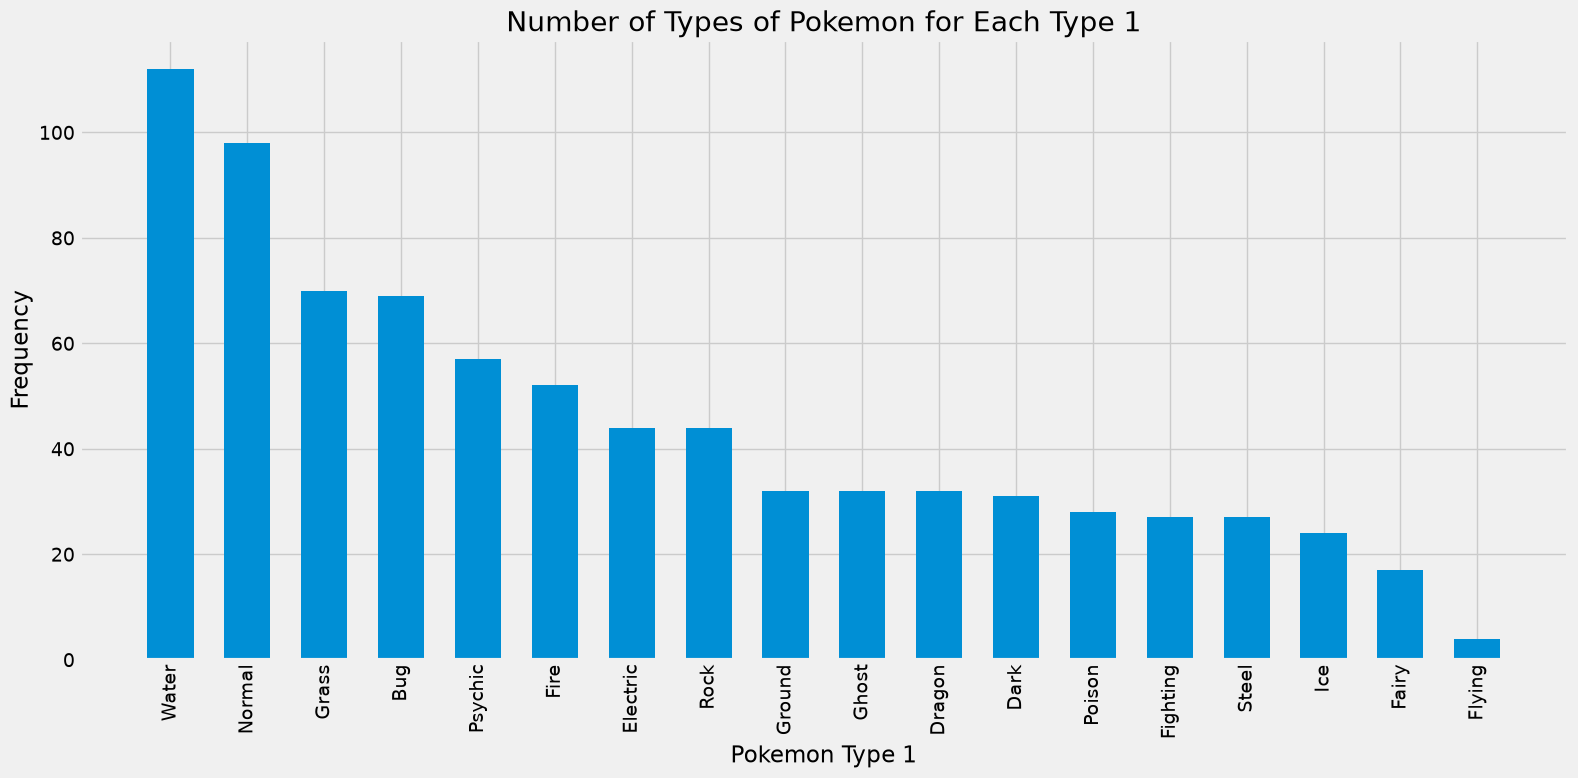

In [19]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(16, 8))
width=0.6

plt.bar(type1_counts.index, type1_counts.values, width=width)

plt.title("Number of Types of Pokemon for Each Type 1")
plt.xlabel("Pokemon Type 1")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [20]:
type2_counts.index

Index(['Flying', 'Ground', 'Poison', 'Psychic', 'Fighting', 'Grass', 'Fairy',
       'Steel', 'Dark', 'Dragon', 'Ice', 'Rock', 'Water', 'Ghost', 'Fire',
       'Electric', 'Normal', 'Bug'],
      dtype='str', name='Type 2')

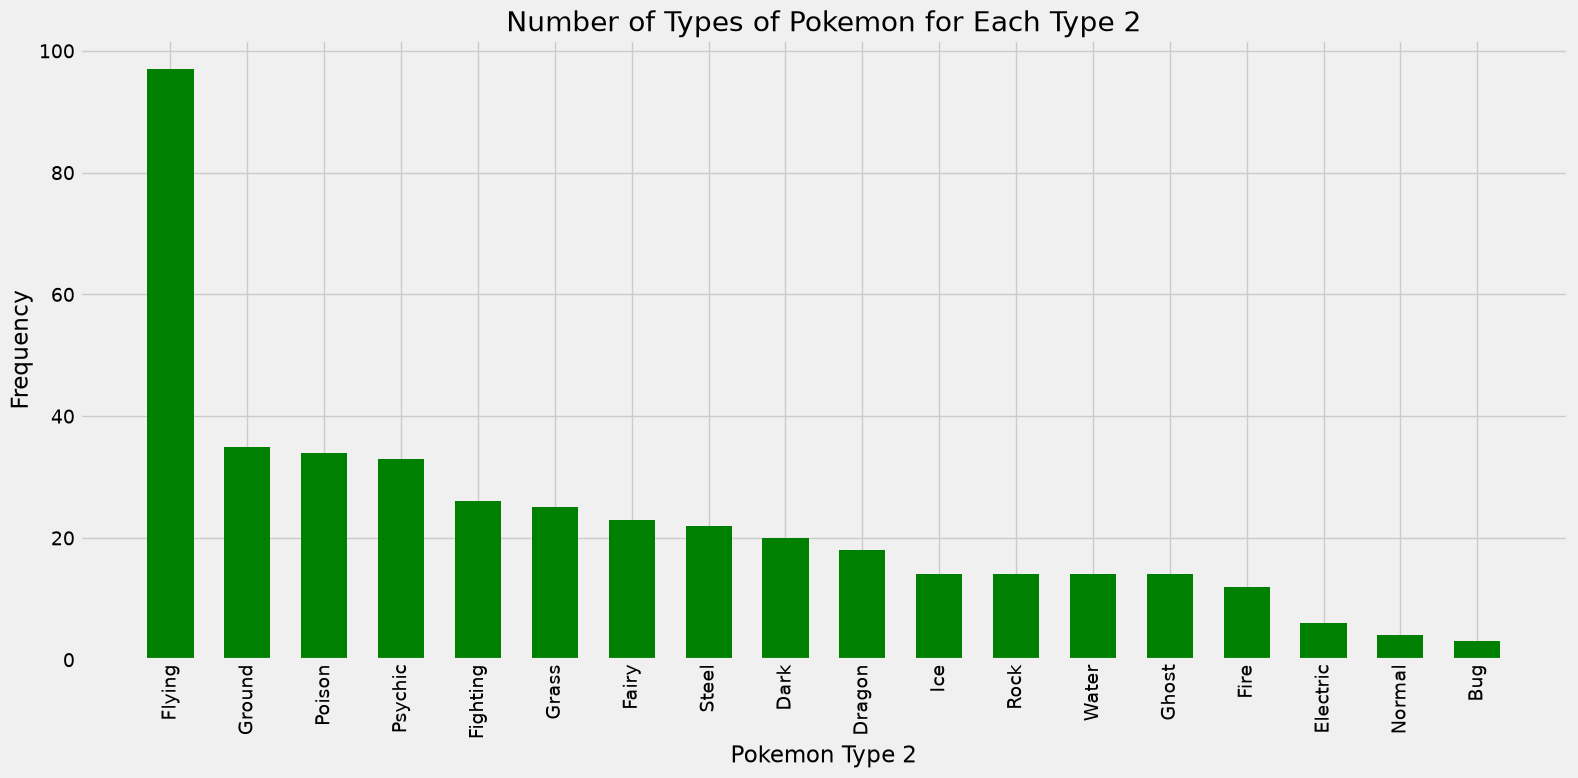

In [21]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(16, 8))
width=0.6

plt.bar(type2_counts.index, type2_counts.values, width=width, color='green')

plt.title("Number of Types of Pokemon for Each Type 2")
plt.xlabel("Pokemon Type 2")
plt.ylabel("Frequency")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [22]:
pokemon['Generation'].value_counts()

Generation
1    166
5    165
3    160
4    121
2    106
6     82
Name: count, dtype: int64

In [23]:
generation = dict(pokemon['Generation'].value_counts())
generation

{1: np.int64(166),
 5: np.int64(165),
 3: np.int64(160),
 4: np.int64(121),
 2: np.int64(106),
 6: np.int64(82)}

In [25]:
gen_counts = generation.values()
gen_counts

dict_values([np.int64(166), np.int64(165), np.int64(160), np.int64(121), np.int64(106), np.int64(82)])

In [26]:
gen_keys = generation.keys()
gen_keys

dict_keys([1, 5, 3, 4, 2, 6])

In [27]:
gens = ['Generation 1', 'Generation 2', 'Generation 3', 'Generation 4', 'Generation 5', 'Generation 6']
gens

['Generation 1',
 'Generation 2',
 'Generation 3',
 'Generation 4',
 'Generation 5',
 'Generation 6']

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


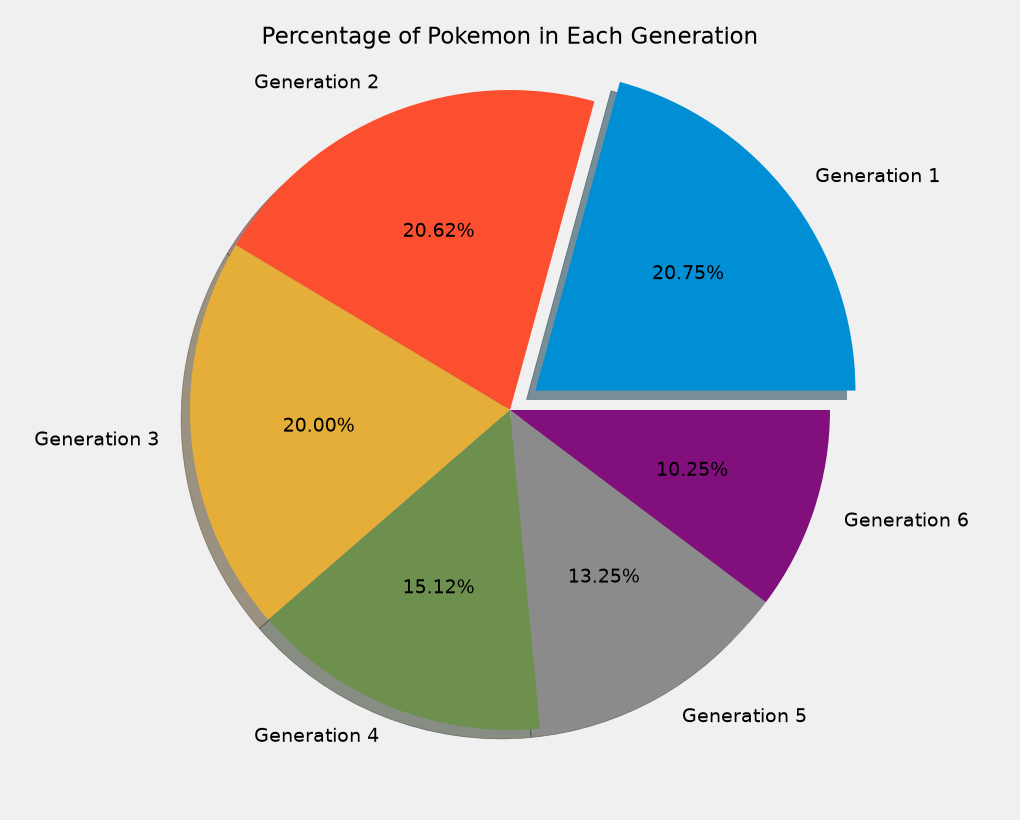

In [28]:
# Pie Chart
fig = plt.figure(figsize=(10, 8))
fig.suptitle("Percentage of Pokemon in Each Generation")
ax3 = fig.add_axes([0, 0, 1, 1])

# "Explodes" first slice
explode = (0.1, 0, 0, 0, 0, 0)
ax3.axis("equal")

plt.pie(gen_counts, labels = gens, autopct="%1.2f%%", shadow=True, explode=explode)

In [29]:
legendaries = dict(pokemon['Legendary'].value_counts())
legendaries

{False: np.int64(735), True: np.int64(65)}

In [30]:
legendaries_counts = legendaries.values()
legendaries_counts

dict_values([np.int64(735), np.int64(65)])

In [31]:
legendaries_class = legendaries.keys()
legendaries_class

dict_keys([False, True])

In [32]:
legendaries_class2 = ["Not Legendary", "Legendary"]
legendaries_class2

['Not Legendary', 'Legendary']

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


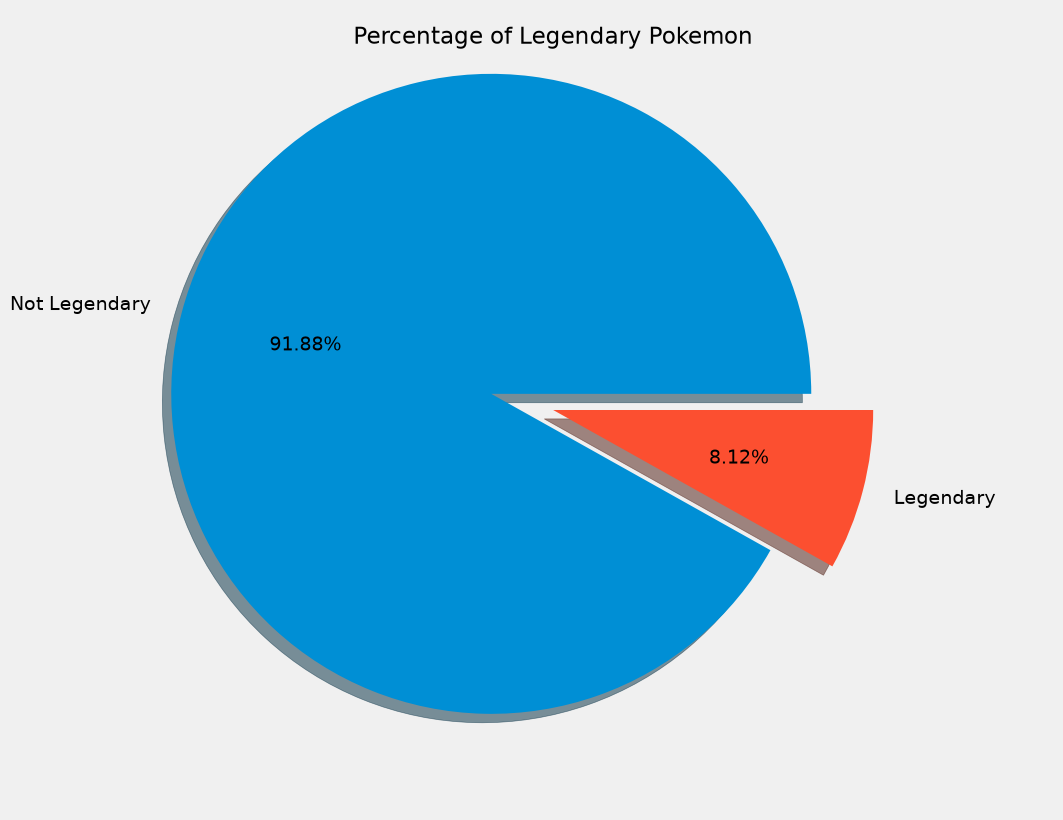

In [33]:
# Pie Chart
fig = plt.figure(figsize=(10, 8))
fig.suptitle("Percentage of Legendary Pokemon")
ax4 = fig.add_axes([0, 0, 1, 1])

# Explodes 1st slice
explode = (0.2, 0)
ax4.axis("equal")

plt.pie(legendaries_counts, labels = legendaries_class2, autopct="%1.2f%%", shadow=True, explode=explode)

In [34]:
# We excluded the  '#' column since it's just the index.
pokemon[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Legendary"]].corr()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
HP,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


### Dealing With Null Values

In [35]:
pokemon['Type 2']

0      Poison
1      Poison
2      Poison
3      Poison
4         NaN
        ...  
795     Fairy
796     Fairy
797     Ghost
798      Dark
799     Water
Name: Type 2, Length: 800, dtype: str

In [36]:
# We will replace it with a category 'NA'
pokemon['Type 2'] = pokemon['Type 2'].fillna('NA')

In [38]:
pokemon['Type 2'].isna().unique()

array([False])

In [39]:
# We have a missing Pokemon name. I googled the pokedex and discovered we were missing Primeape.
pokemon[pokemon['Name'].isna()]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NA,65,105,60,60,70,95,1,False


In [40]:
pokemon.iloc[60:70, :]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
60,61,Golduck,Water,NA,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,NA,40,80,35,35,45,70,1,False
62,63,NaN,Fighting,NA,65,105,60,60,70,95,1,False
63,64,Growlithe,Fire,NA,55,70,45,70,50,60,1,False
64,65,Arcanine,Fire,NA,90,110,80,100,80,95,1,False
65,66,Poliwag,Water,NA,40,50,40,40,40,90,1,False
66,67,Poliwhirl,Water,NA,65,65,65,50,50,90,1,False
67,68,Poliwrath,Water,Fighting,90,95,95,70,90,70,1,False
68,69,Abra,Psychic,NA,25,20,15,105,55,90,1,False
69,70,Kadabra,Psychic,NA,40,35,30,120,70,105,1,False


In [41]:
pokemon['Name'][62]

nan

In [42]:
pokemon.loc[62, 'Name'] = 'Primeape'

In [43]:
pokemon.iloc[60:70, :]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
60,61,Golduck,Water,NA,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,NA,40,80,35,35,45,70,1,False
62,63,Primeape,Fighting,NA,65,105,60,60,70,95,1,False
63,64,Growlithe,Fire,NA,55,70,45,70,50,60,1,False
64,65,Arcanine,Fire,NA,90,110,80,100,80,95,1,False
65,66,Poliwag,Water,NA,40,50,40,40,40,90,1,False
66,67,Poliwhirl,Water,NA,65,65,65,50,50,90,1,False
67,68,Poliwrath,Water,Fighting,90,95,95,70,90,70,1,False
68,69,Abra,Psychic,NA,25,20,15,105,55,90,1,False
69,70,Kadabra,Psychic,NA,40,35,30,120,70,105,1,False


In [44]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      800 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 83.4 KB


In [45]:
combats.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [46]:
tests.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   10000 non-null  int64
 1   Second_pokemon  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


In [47]:
pokemon[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500
std,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000
50%,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000
75%,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000
max,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000


In [48]:
gen1 = pokemon[pokemon['Generation'] == 1]
gen2 = pokemon[pokemon['Generation'] == 2]
gen3 = pokemon[pokemon['Generation'] == 3]
gen4 = pokemon[pokemon['Generation'] == 4]
gen5 = pokemon[pokemon['Generation'] == 5]
gen6 = pokemon[pokemon['Generation'] == 6]

In [49]:
gen1_stats = gen1[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen1_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,65.819277,76.638554,70.861446,71.819277,69.090361,72.584337
std,28.153968,30.744727,28.641336,34.439106,25.505275,29.675857
min,10.000000,5.000000,5.000000,15.000000,20.000000,15.000000
25%,46.500000,55.000000,50.000000,45.000000,50.000000,50.000000
50%,62.000000,75.000000,66.000000,65.000000,70.000000,70.000000
75%,80.000000,95.000000,85.000000,95.000000,85.000000,92.250000
max,250.000000,190.000000,180.000000,194.000000,130.000000,150.000000


In [50]:
gen2_stats = gen2[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen2_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,71.207547,72.028302,73.386792,65.943396,73.905660,61.811321
std,30.589359,32.708658,39.233749,27.814977,31.534268,27.263132
min,20.000000,10.000000,10.000000,10.000000,20.000000,5.000000
25%,51.250000,50.000000,45.750000,40.000000,55.000000,40.000000
50%,70.000000,73.500000,70.000000,65.000000,65.000000,60.500000
75%,88.750000,90.000000,90.000000,84.500000,95.000000,85.000000
max,255.000000,185.000000,230.000000,165.000000,230.000000,130.000000


In [51]:
gen3_stats = gen3[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen3_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,160.000000,160.000000,160.000000,160.00000,160.000000,160.000000
mean,66.543750,81.625000,74.100000,75.80625,71.225000,66.925000
std,24.059634,36.593767,35.222599,35.40751,31.039628,31.331972
min,1.000000,15.000000,20.000000,10.00000,20.000000,10.000000
25%,50.000000,54.000000,50.000000,50.00000,50.000000,47.250000
50%,65.000000,75.000000,67.500000,70.00000,65.000000,65.000000
75%,80.000000,100.000000,90.000000,95.00000,87.000000,86.250000
max,170.000000,180.000000,230.000000,180.00000,200.000000,180.000000


In [52]:
gen4_stats = gen4[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen4_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,73.082645,82.867769,78.132231,76.404959,77.190083,71.338843
std,25.113604,32.780569,30.145741,31.907047,27.498883,28.475005
min,20.000000,5.000000,5.000000,10.000000,30.000000,5.000000
25%,55.000000,62.000000,51.000000,54.000000,55.000000,46.000000
50%,70.000000,80.000000,72.000000,71.000000,75.000000,77.000000
75%,85.000000,103.000000,105.000000,100.000000,100.000000,91.000000
max,150.000000,170.000000,168.000000,150.000000,150.000000,135.000000


In [53]:
gen5_stats = gen5[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen5_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,71.787879,82.066667,72.327273,71.987879,68.739394,68.078788
std,22.407748,30.365685,23.318883,31.889097,22.388721,28.726632
min,30.000000,25.000000,30.000000,15.000000,25.000000,10.000000
25%,55.000000,55.000000,55.000000,45.000000,50.000000,45.000000
50%,70.000000,80.000000,70.000000,65.000000,65.000000,65.000000
75%,85.000000,103.000000,90.000000,95.000000,85.000000,95.000000
max,165.000000,170.000000,145.000000,170.000000,135.000000,145.000000


In [54]:
gen6_stats = gen6[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].describe()
gen6_stats

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,68.268293,75.804878,76.682927,74.292683,74.890244,66.439024
std,20.907822,29.179495,31.370301,31.790785,30.086298,25.691954
min,38.000000,22.000000,33.000000,27.000000,25.000000,23.000000
25%,53.250000,53.250000,55.500000,50.000000,55.000000,48.250000
50%,65.000000,69.500000,70.000000,65.000000,70.500000,60.000000
75%,80.000000,94.250000,89.500000,95.250000,89.000000,80.000000
max,126.000000,160.000000,184.000000,170.000000,154.000000,126.000000


In [55]:
# Getting the count of the HP column for Gen 6. (iloc)
gen6_stats.iloc[0, :1]

HP    82.0
Name: count, dtype: float64

In [56]:
gen6_stats.iloc[1, :1]

HP    68.268293
Name: mean, dtype: float64

In [57]:
gen6_stats.loc['mean', 'HP']

np.float64(68.26829268292683)

In [58]:
gen6_stats.loc['mean', 'HP': 'Defense']

HP         68.268293
Attack     75.804878
Defense    76.682927
Name: mean, dtype: float64

In [60]:
pd.DataFrame(gen6_stats.loc['mean', 'HP': 'Defense'])

,mean
HP,68.268293
Attack,75.804878
Defense,76.682927


In [61]:
# Average of the HP for Each Generation
gen1_average_hp = gen1_stats.loc['mean', 'HP']
gen2_average_hp = gen2_stats.loc['mean', 'HP']
gen3_average_hp = gen3_stats.loc['mean', 'HP']
gen4_average_hp = gen4_stats.loc['mean', 'HP']
gen5_average_hp = gen5_stats.loc['mean', 'HP']
gen6_average_hp = gen6_stats.loc['mean', 'HP']

In [62]:
# Average of the Attack for Each Generation
gen1_average_attack = gen1_stats.loc['mean', 'Attack']
gen2_average_attack = gen2_stats.loc['mean', 'Attack']
gen3_average_attack = gen3_stats.loc['mean', 'Attack']
gen4_average_attack = gen4_stats.loc['mean', 'Attack']
gen5_average_attack = gen5_stats.loc['mean', 'Attack']
gen6_average_attack = gen6_stats.loc['mean', 'Attack']

In [63]:
# Average of the Defense for Each Generation
gen1_average_defense = gen1_stats.loc['mean', 'Defense']
gen2_average_defense = gen2_stats.loc['mean', 'Defense']
gen3_average_defense = gen3_stats.loc['mean', 'Defense']
gen4_average_defense = gen4_stats.loc['mean', 'Defense']
gen5_average_defense = gen5_stats.loc['mean', 'Defense']
gen6_average_defense = gen6_stats.loc['mean', 'Defense']

In [64]:
# Average of the Special Attack for Each Generation
gen1_average_sfatk = gen1_stats.loc['mean', 'Sp. Atk']
gen2_average_sfatk = gen2_stats.loc['mean', 'Sp. Atk']
gen3_average_sfatk = gen3_stats.loc['mean', 'Sp. Atk']
gen4_average_sfatk = gen4_stats.loc['mean', 'Sp. Atk']
gen5_average_sfatk = gen5_stats.loc['mean', 'Sp. Atk']
gen6_average_sfatk = gen6_stats.loc['mean', 'Sp. Atk']

In [65]:
# Average of the Special Defense for Each Generation
gen1_average_sfdef = gen1_stats.loc['mean', 'Sp. Def']
gen2_average_sfdef = gen2_stats.loc['mean', 'Sp. Def']
gen3_average_sfdef = gen3_stats.loc['mean', 'Sp. Def']
gen4_average_sfdef = gen4_stats.loc['mean', 'Sp. Def']
gen5_average_sfdef = gen5_stats.loc['mean', 'Sp. Def']
gen6_average_sfdef = gen6_stats.loc['mean', 'Sp. Def']

In [66]:
# Average of the Defense for Each Generation
gen1_average_speed = gen1_stats.loc['mean', 'Speed']
gen2_average_speed = gen2_stats.loc['mean', 'Speed']
gen3_average_speed = gen3_stats.loc['mean', 'Speed']
gen4_average_speed = gen4_stats.loc['mean', 'Speed']
gen5_average_speed = gen5_stats.loc['mean', 'Speed']
gen6_average_speed = gen6_stats.loc['mean', 'Speed']

In [67]:
# Dictionary of Average Pokemon Stats
poke_stats_dict = {1: [gen1_average_hp, gen1_average_attack, gen1_average_defense, gen1_average_sfatk, gen1_average_sfdef, gen1_average_speed], 
                  2: [gen2_average_hp, gen2_average_attack, gen2_average_defense, gen2_average_sfatk, gen2_average_sfdef, gen2_average_speed], 
                  3: [gen3_average_hp, gen3_average_attack, gen3_average_defense, gen3_average_sfatk, gen3_average_sfdef, gen3_average_speed], 
                  4: [gen4_average_hp, gen4_average_attack, gen4_average_defense, gen4_average_sfatk, gen4_average_sfdef, gen4_average_speed], 
                  5: [gen5_average_hp, gen5_average_attack, gen5_average_defense, gen5_average_sfatk, gen5_average_sfdef, gen5_average_speed], 
                  6: [gen6_average_hp, gen6_average_attack, gen6_average_defense, gen6_average_sfatk, gen6_average_sfdef, gen6_average_speed]}

In [68]:
poke_stats_dict

{1: [np.float64(65.81927710843374),
  np.float64(76.63855421686748),
  np.float64(70.86144578313252),
  np.float64(71.81927710843374),
  np.float64(69.09036144578313),
  np.float64(72.58433734939759)],
 2: [np.float64(71.20754716981132),
  np.float64(72.02830188679245),
  np.float64(73.38679245283019),
  np.float64(65.94339622641509),
  np.float64(73.90566037735849),
  np.float64(61.81132075471698)],
 3: [np.float64(66.54375),
  np.float64(81.625),
  np.float64(74.1),
  np.float64(75.80625),
  np.float64(71.225),
  np.float64(66.925)],
 4: [np.float64(73.08264462809917),
  np.float64(82.86776859504133),
  np.float64(78.13223140495867),
  np.float64(76.40495867768595),
  np.float64(77.1900826446281),
  np.float64(71.33884297520662)],
 5: [np.float64(71.78787878787878),
  np.float64(82.06666666666666),
  np.float64(72.32727272727273),
  np.float64(71.98787878787878),
  np.float64(68.73939393939393),
  np.float64(68.07878787878788)],
 6: [np.float64(68.26829268292683),
  np.float64(75.804

In [69]:
tuple(poke_stats_dict.keys())

(1, 2, 3, 4, 5, 6)

In [70]:
poke_stats_dict.get(1)

[np.float64(65.81927710843374),
 np.float64(76.63855421686748),
 np.float64(70.86144578313252),
 np.float64(71.81927710843374),
 np.float64(69.09036144578313),
 np.float64(72.58433734939759)]

In [71]:
poke_stats_dict.items()

dict_items([(1, [np.float64(65.81927710843374), np.float64(76.63855421686748), np.float64(70.86144578313252), np.float64(71.81927710843374), np.float64(69.09036144578313), np.float64(72.58433734939759)]), (2, [np.float64(71.20754716981132), np.float64(72.02830188679245), np.float64(73.38679245283019), np.float64(65.94339622641509), np.float64(73.90566037735849), np.float64(61.81132075471698)]), (3, [np.float64(66.54375), np.float64(81.625), np.float64(74.1), np.float64(75.80625), np.float64(71.225), np.float64(66.925)]), (4, [np.float64(73.08264462809917), np.float64(82.86776859504133), np.float64(78.13223140495867), np.float64(76.40495867768595), np.float64(77.1900826446281), np.float64(71.33884297520662)]), (5, [np.float64(71.78787878787878), np.float64(82.06666666666666), np.float64(72.32727272727273), np.float64(71.98787878787878), np.float64(68.73939393939393), np.float64(68.07878787878788)]), (6, [np.float64(68.26829268292683), np.float64(75.8048780487805), np.float64(76.68292682

In [72]:
list(poke_stats_dict.values())[0][1]

np.float64(76.63855421686748)

In [73]:
def extract_stats(stat_position):
    lst = []
    for i in range(len(list(poke_stats_dict.keys()))):
        lst.append(list(poke_stats_dict.values())[i][stat_position])
    return lst

In [74]:
hp_average_list = extract_stats(0)
attack_average_list = extract_stats(1)
defense_average_list = extract_stats(2)
spatk_average_list = extract_stats(3)
spdef_average_list = extract_stats(4)
speed_average_list = extract_stats(5)

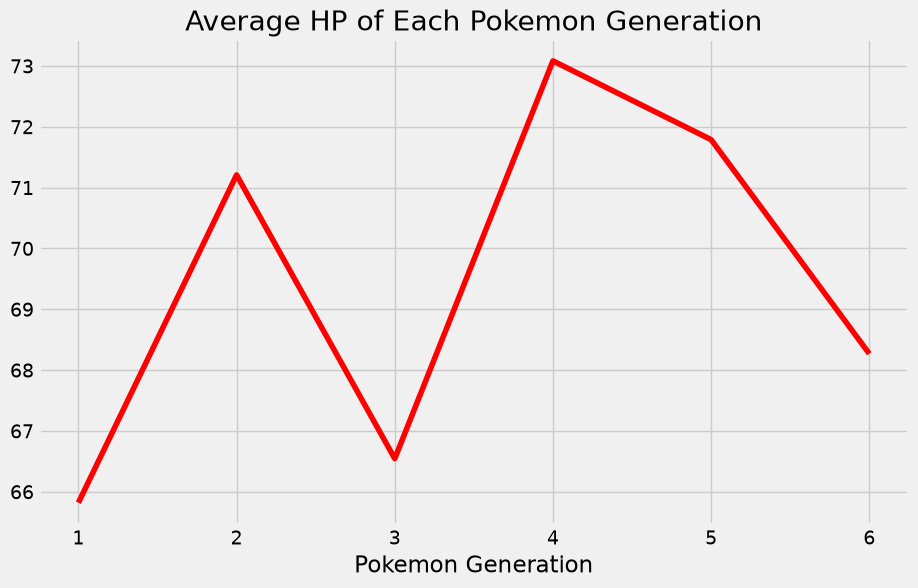

In [75]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y=tuple(hp_average_list), data=poke_stats_dict, 
                  color="red")

ax.set(xlabel="Pokemon Generation", label="Average HP")

plt.title("Average HP of Each Pokemon Generation")
plt.show()

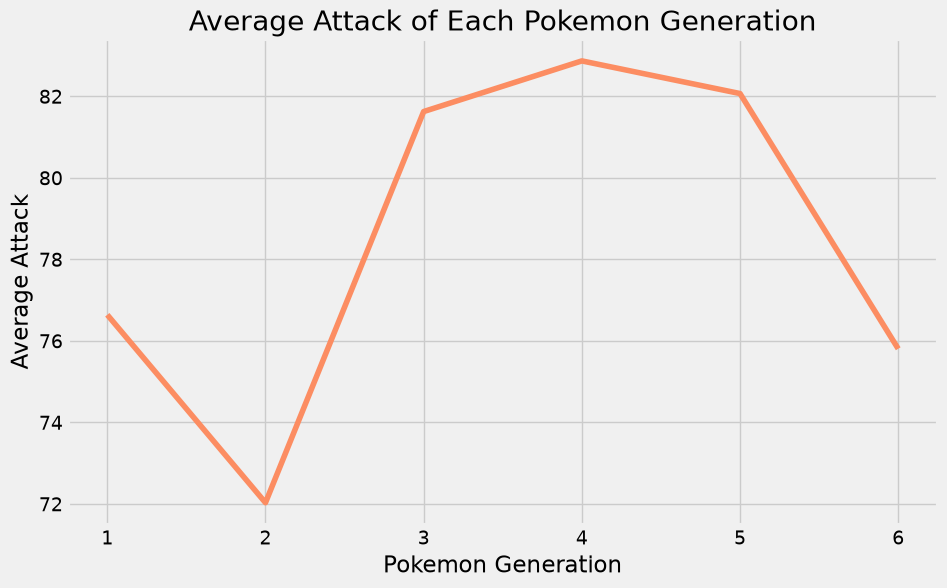

In [76]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y = tuple(attack_average_list), data= poke_stats_dict, 
              color = sns.color_palette("Set2")[1])
ax.set(xlabel="Pokemon Generation", ylabel="Average Attack")

plt.title("Average Attack of Each Pokemon Generation")
plt.show()

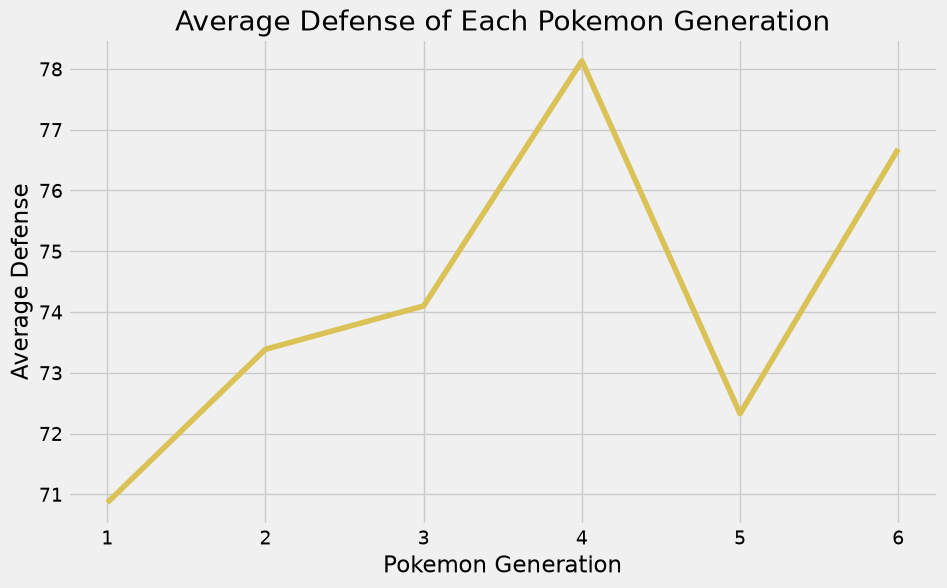

In [77]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y = tuple(defense_average_list), data= poke_stats_dict, 
              color = sns.color_palette("hls", 8)[1])
ax.set(xlabel="Pokemon Generation", ylabel="Average Defense")

plt.title("Average Defense of Each Pokemon Generation")
plt.show()

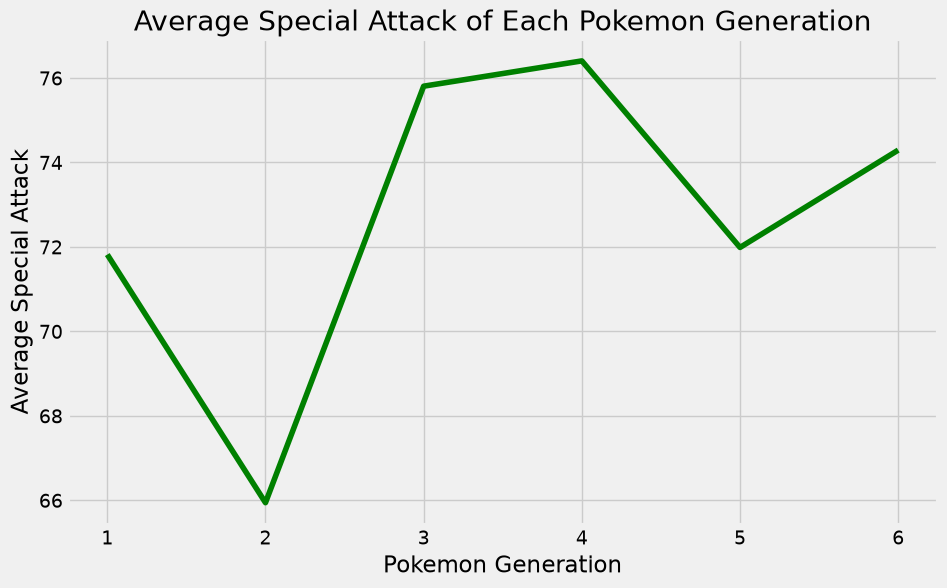

In [78]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y = tuple(spatk_average_list), data= poke_stats_dict, 
              color ="green")
ax.set(xlabel="Pokemon Generation", ylabel="Average Special Attack")

plt.title("Average Special Attack of Each Pokemon Generation")
plt.show()

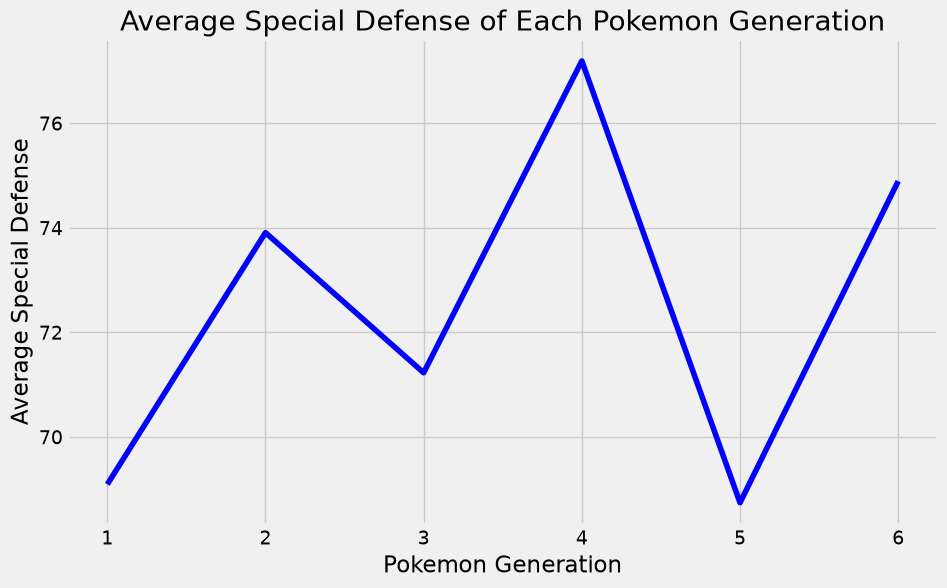

In [79]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y = tuple(spdef_average_list), data= poke_stats_dict, 
              color="blue")
ax.set(xlabel="Pokemon Generation", ylabel="Average Special Defense")

plt.title("Average Special Defense of Each Pokemon Generation")
plt.show()

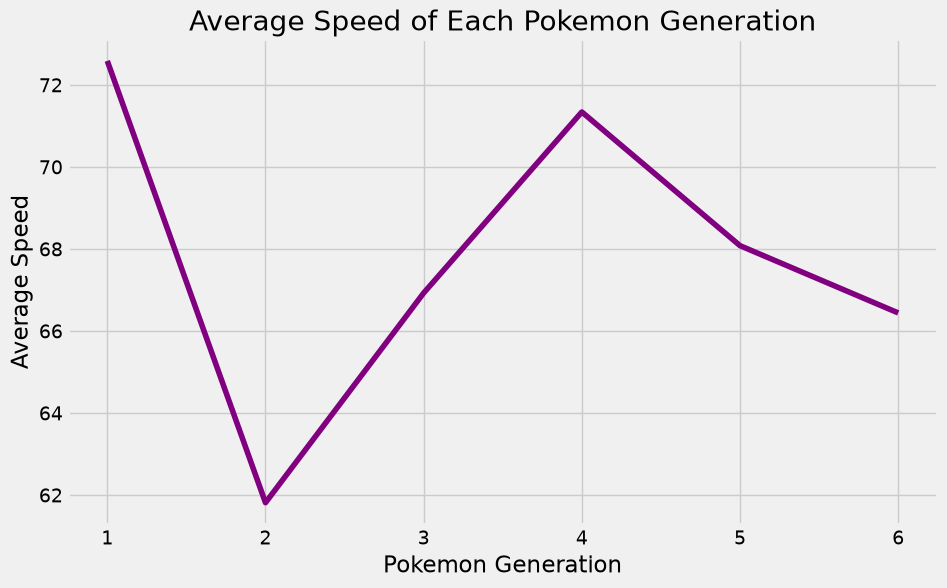

In [80]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(6)

ax = sns.lineplot(x=tuple(poke_stats_dict.keys()), y = tuple(speed_average_list), data= poke_stats_dict, 
              color="purple")
ax.set(xlabel="Pokemon Generation", ylabel="Average Speed")

plt.title("Average Speed of Each Pokemon Generation")
plt.show()

### Creating Dummy Variables for Categorical Variables

In [81]:
categorical_cols = ['Type 1', 'Type 2', 'Generation', 'Legendary']
categorical_cols

['Type 1', 'Type 2', 'Generation', 'Legendary']

In [82]:
pokemon_enc = pd.get_dummies(pokemon, columns=categorical_cols)
pokemon_enc

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary_False,Legendary_True
0,1,Bulbasaur,45,49,49,65,65,45,False,False,...,False,False,True,False,False,False,False,False,True,False
1,2,Ivysaur,60,62,63,80,80,60,False,False,...,False,False,True,False,False,False,False,False,True,False
2,3,Venusaur,80,82,83,100,100,80,False,False,...,False,False,True,False,False,False,False,False,True,False
3,4,Mega Venusaur,80,100,123,122,120,80,False,False,...,False,False,True,False,False,False,False,False,True,False
4,5,Charmander,39,52,43,60,50,65,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,50,100,150,100,150,50,False,False,...,False,False,False,False,False,False,False,True,False,True
796,797,Mega Diancie,50,160,110,160,110,110,False,False,...,False,False,False,False,False,False,False,True,False,True
797,798,Hoopa Confined,80,110,60,150,130,70,False,False,...,False,False,False,False,False,False,False,True,False,True
798,799,Hoopa Unbound,80,160,60,170,130,80,False,False,...,False,False,False,False,False,False,False,True,False,True


In [83]:
pokemon_enc.iloc[265:269, :]

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary_False,Legendary_True
265,266,Larvitar,50,64,50,45,50,41,False,False,...,False,False,False,True,False,False,False,False,True,False
266,267,Pupitar,70,84,70,65,70,51,False,False,...,False,False,False,True,False,False,False,False,True,False
267,268,Tyranitar,100,134,110,95,100,61,False,False,...,False,False,False,True,False,False,False,False,True,False
268,269,Mega Tyranitar,100,164,150,95,120,71,False,False,...,False,False,False,True,False,False,False,False,True,False


In [84]:
pokemon_enc.iloc[265:269, 0:7]

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def
265,266,Larvitar,50,64,50,45,50
266,267,Pupitar,70,84,70,65,70
267,268,Tyranitar,100,134,110,95,100
268,269,Mega Tyranitar,100,164,150,95,120


In [85]:
pokemon_enc.loc[265:269, 'Name']

265          Larvitar
266           Pupitar
267         Tyranitar
268    Mega Tyranitar
269             Lugia
Name: Name, dtype: str

In [86]:
pokemon_enc.loc[265:269, 'Name': 'Speed']

,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
265,Larvitar,50,64,50,45,50,41
266,Pupitar,70,84,70,65,70,51
267,Tyranitar,100,134,110,95,100,61
268,Mega Tyranitar,100,164,150,95,120,71
269,Lugia,106,90,130,90,154,110


In [87]:
pokemon['Legendary']

0      False
1      False
2      False
3      False
4      False
       ...  
795     True
796     True
797     True
798     True
799     True
Name: Legendary, Length: 800, dtype: bool

In [88]:
pokemon['Legendary'] = pokemon['Legendary'].astype(int)

In [89]:
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,0
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,0
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,0
4,5,Charmander,Fire,NA,39,52,43,60,50,65,1,0


In [93]:
pokemon_enc['Legendary'] = pokemon['Legendary'].astype(int)
pokemon_enc.head()

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary_False,Legendary_True,Legendary
0,1,Bulbasaur,45,49,49,65,65,45,False,False,...,False,True,False,False,False,False,False,True,False,0
1,2,Ivysaur,60,62,63,80,80,60,False,False,...,False,True,False,False,False,False,False,True,False,0
2,3,Venusaur,80,82,83,100,100,80,False,False,...,False,True,False,False,False,False,False,True,False,0
3,4,Mega Venusaur,80,100,123,122,120,80,False,False,...,False,True,False,False,False,False,False,True,False,0
4,5,Charmander,39,52,43,60,50,65,False,False,...,False,True,False,False,False,False,False,True,False,0


In [94]:
pokemon_enc = pokemon_enc.drop(columns=['Legendary_False', 'Legendary_True'])
pokemon_enc.head()

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary
0,1,Bulbasaur,45,49,49,65,65,45,False,False,...,False,False,False,True,False,False,False,False,False,0
1,2,Ivysaur,60,62,63,80,80,60,False,False,...,False,False,False,True,False,False,False,False,False,0
2,3,Venusaur,80,82,83,100,100,80,False,False,...,False,False,False,True,False,False,False,False,False,0
3,4,Mega Venusaur,80,100,123,122,120,80,False,False,...,False,False,False,True,False,False,False,False,False,0
4,5,Charmander,39,52,43,60,50,65,False,False,...,False,False,False,True,False,False,False,False,False,0


### Using FeatureHasher

* Use FeatureHasher to convert columns “Type 1” and “Type 2” into numerical values. This solves the problem of having a large number of columns (when the number of categories is extremely large) due to one-hot encoding.

* FeatureHasher is a class in the sklearn.feature_extraction module of the Python Scikit-learn library, designed to efficiently convert categorical or textual data into numerical feature vectors using a technique called hashing trick. It is particularly useful when working with high-dimensional, sparse data, like text or categorical features, and where the size of the feature set is large or unknown.

In [90]:
len(pokemon['Type 1'].unique())

18

In [91]:
len(pokemon['Type 2'].unique())

19

In [95]:
pokemon_enc.head()

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary
0,1,Bulbasaur,45,49,49,65,65,45,False,False,...,False,False,False,True,False,False,False,False,False,0
1,2,Ivysaur,60,62,63,80,80,60,False,False,...,False,False,False,True,False,False,False,False,False,0
2,3,Venusaur,80,82,83,100,100,80,False,False,...,False,False,False,True,False,False,False,False,False,0
3,4,Mega Venusaur,80,100,123,122,120,80,False,False,...,False,False,False,True,False,False,False,False,False,0
4,5,Charmander,39,52,43,60,50,65,False,False,...,False,False,False,True,False,False,False,False,False,0


* OneHotEncoder is designed specifically for categorical variables like Pokémon types. 

* FeatureHasher is a more general-purpose tool that trades interpretability for fixed-size representations.

In [96]:
encoder = OneHotEncoder(handle_unknown='ignore')

types = encoder.fit_transform(pokemon[['Type 1', 'Type 2']])

types = pd.DataFrame(
    types.toarray(),
    columns=encoder.get_feature_names_out(['Type 1', 'Type 2'])
)

In [97]:
# We get interpretability with OneHotEncoder
encoder.get_feature_names_out()

array(['Type 1_Bug', 'Type 1_Dark', 'Type 1_Dragon', 'Type 1_Electric',
       'Type 1_Fairy', 'Type 1_Fighting', 'Type 1_Fire', 'Type 1_Flying',
       'Type 1_Ghost', 'Type 1_Grass', 'Type 1_Ground', 'Type 1_Ice',
       'Type 1_Normal', 'Type 1_Poison', 'Type 1_Psychic', 'Type 1_Rock',
       'Type 1_Steel', 'Type 1_Water', 'Type 2_Bug', 'Type 2_Dark',
       'Type 2_Dragon', 'Type 2_Electric', 'Type 2_Fairy',
       'Type 2_Fighting', 'Type 2_Fire', 'Type 2_Flying', 'Type 2_Ghost',
       'Type 2_Grass', 'Type 2_Ground', 'Type 2_Ice', 'Type 2_NA',
       'Type 2_Normal', 'Type 2_Poison', 'Type 2_Psychic', 'Type 2_Rock',
       'Type 2_Steel', 'Type 2_Water'], dtype=object)

In [98]:
types

,Type 1_Bug,Type 1_Dark,Type 1_Dragon,Type 1_Electric,Type 1_Fairy,Type 1_Fighting,Type 1_Fire,Type 1_Flying,Type 1_Ghost,Type 1_Grass,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_NA,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### We will now combine the two datasets together.
Our goal is to concatenate the features from the 'pokemon' dataset to the 'combats' dataset. We will get the stats, whether or not the pokemon is a legendary and the generation its from for both the losing pokemon and the winner pokemon.

In [99]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [100]:
combats2 = combats.copy(deep=True)
combats2

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151
...,...,...,...
49995,707,126,707
49996,589,664,589
49997,303,368,368
49998,109,89,109


In [101]:
pokemon_enc.head()

,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Type 1_Bug,Type 1_Dark,...,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary
0,1,Bulbasaur,45,49,49,65,65,45,False,False,...,False,False,False,True,False,False,False,False,False,0
1,2,Ivysaur,60,62,63,80,80,60,False,False,...,False,False,False,True,False,False,False,False,False,0
2,3,Venusaur,80,82,83,100,100,80,False,False,...,False,False,False,True,False,False,False,False,False,0
3,4,Mega Venusaur,80,100,123,122,120,80,False,False,...,False,False,False,True,False,False,False,False,False,0
4,5,Charmander,39,52,43,60,50,65,False,False,...,False,False,False,True,False,False,False,False,False,0


### Merging the First Pokemon with the "Pokemon" dataset

In [102]:
merging_first_pokemon = combats2.merge(pokemon_enc, how='left', left_on=['First_pokemon'], right_on=['#'])
merging_first_pokemon

,First_pokemon,Second_pokemon,Winner,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,...,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary
0,266,298,298,266,Larvitar,50,64,50,45,50,...,False,False,False,False,True,False,False,False,False,0
1,702,701,701,702,Virizion,91,90,72,90,129,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,191,Togetic,55,40,85,80,105,...,False,False,False,False,True,False,False,False,False,0
3,237,683,683,237,Slugma,40,40,40,70,40,...,False,False,False,False,True,False,False,False,False,0
4,151,231,151,151,Omastar,70,60,125,115,70,...,False,False,True,True,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,707,126,707,707,Reshiram,100,120,100,150,120,...,False,False,False,False,False,False,False,True,False,1
49996,589,664,589,589,Drilbur,60,85,40,30,45,...,False,False,False,False,False,False,False,True,False,0
49997,303,368,368,303,Pelipper,60,50,100,85,70,...,False,False,False,False,False,True,False,False,False,0
49998,109,89,109,109,Voltorb,40,30,50,55,55,...,False,False,False,True,False,False,False,False,False,0


In [103]:
pokemon.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk',
       'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')

In [104]:
len(pokemon.columns)

12

In [105]:
pokemon.columns.values

<ArrowStringArray>
[         '#',       'Name',     'Type 1',     'Type 2',         'HP',
     'Attack',    'Defense',    'Sp. Atk',    'Sp. Def',      'Speed',
 'Generation',  'Legendary']
Length: 12, dtype: str

In [106]:
pokemon.columns.values[2]

'Type 1'

In [107]:
pokemon.columns.values[2] + str(" test")

'Type 1 test'

In [108]:
# Function to rename our columns for us so we can distinguish between the first pokemon's stats and the second one's.
def update_column_names(data, added_string):
    # for i in range(len(data.columns)):
        # We are just appending a string at the end of each column
        # data.columns.values[i] = str(data.columns.values[i]) + str(added_string)
    data.columns = [str(col) + str(added_string) for col in data.columns]
    return data

In [109]:
update_column_names(merging_first_pokemon, ' 1st')

,First_pokemon 1st,Second_pokemon 1st,Winner 1st,# 1st,Name 1st,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,...,Type 2_Rock 1st,Type 2_Steel 1st,Type 2_Water 1st,Generation_1 1st,Generation_2 1st,Generation_3 1st,Generation_4 1st,Generation_5 1st,Generation_6 1st,Legendary 1st
0,266,298,298,266,Larvitar,50,64,50,45,50,...,False,False,False,False,True,False,False,False,False,0
1,702,701,701,702,Virizion,91,90,72,90,129,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,191,Togetic,55,40,85,80,105,...,False,False,False,False,True,False,False,False,False,0
3,237,683,683,237,Slugma,40,40,40,70,40,...,False,False,False,False,True,False,False,False,False,0
4,151,231,151,151,Omastar,70,60,125,115,70,...,False,False,True,True,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,707,126,707,707,Reshiram,100,120,100,150,120,...,False,False,False,False,False,False,False,True,False,1
49996,589,664,589,589,Drilbur,60,85,40,30,45,...,False,False,False,False,False,False,False,True,False,0
49997,303,368,368,303,Pelipper,60,50,100,85,70,...,False,False,False,False,False,True,False,False,False,0
49998,109,89,109,109,Voltorb,40,30,50,55,55,...,False,False,False,True,False,False,False,False,False,0


In [110]:
merging_first_pokemon.columns

Index(['First_pokemon 1st', 'Second_pokemon 1st', 'Winner 1st', '# 1st',
       'Name 1st', 'HP 1st', 'Attack 1st', 'Defense 1st', 'Sp. Atk 1st',
       'Sp. Def 1st', 'Speed 1st', 'Type 1_Bug 1st', 'Type 1_Dark 1st',
       'Type 1_Dragon 1st', 'Type 1_Electric 1st', 'Type 1_Fairy 1st',
       'Type 1_Fighting 1st', 'Type 1_Fire 1st', 'Type 1_Flying 1st',
       'Type 1_Ghost 1st', 'Type 1_Grass 1st', 'Type 1_Ground 1st',
       'Type 1_Ice 1st', 'Type 1_Normal 1st', 'Type 1_Poison 1st',
       'Type 1_Psychic 1st', 'Type 1_Rock 1st', 'Type 1_Steel 1st',
       'Type 1_Water 1st', 'Type 2_Bug 1st', 'Type 2_Dark 1st',
       'Type 2_Dragon 1st', 'Type 2_Electric 1st', 'Type 2_Fairy 1st',
       'Type 2_Fighting 1st', 'Type 2_Fire 1st', 'Type 2_Flying 1st',
       'Type 2_Ghost 1st', 'Type 2_Grass 1st', 'Type 2_Ground 1st',
       'Type 2_Ice 1st', 'Type 2_NA 1st', 'Type 2_Normal 1st',
       'Type 2_Poison 1st', 'Type 2_Psychic 1st', 'Type 2_Rock 1st',
       'Type 2_Steel 1st', 'Type 

### Merging the Second Pokemon with the "Pokemon" dataset

In [111]:
merging_second_pokemon = combats2.merge(pokemon_enc, how="left", left_on=["Second_pokemon"], right_on=["#"])
merging_second_pokemon

,First_pokemon,Second_pokemon,Winner,#,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,...,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6,Legendary
0,266,298,298,298,Nuzleaf,70,70,40,60,40,...,False,False,False,False,False,True,False,False,False,0
1,702,701,701,701,Terrakion,91,129,90,72,90,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,668,Beheeyem,75,75,75,125,95,...,False,False,False,False,False,False,False,True,False,0
3,237,683,683,683,Druddigon,77,120,90,60,90,...,False,False,False,False,False,False,False,True,False,0
4,151,231,151,231,Shuckle,20,10,230,10,230,...,True,False,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,707,126,707,126,Horsea,30,40,70,70,25,...,False,False,False,True,False,False,False,False,False,0
49996,589,664,589,664,Tynamo,35,55,40,45,40,...,False,False,False,False,False,False,False,True,False,0
49997,303,368,368,368,Zangoose,73,115,60,60,60,...,False,False,False,False,False,True,False,False,False,0
49998,109,89,109,89,Magnemite,25,35,70,95,55,...,False,True,False,True,False,False,False,False,False,0


In [112]:
update_column_names(merging_second_pokemon, ' 2nd')

,First_pokemon 2nd,Second_pokemon 2nd,Winner 2nd,# 2nd,Name 2nd,HP 2nd,Attack 2nd,Defense 2nd,Sp. Atk 2nd,Sp. Def 2nd,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,266,298,298,298,Nuzleaf,70,70,40,60,40,...,False,False,False,False,False,True,False,False,False,0
1,702,701,701,701,Terrakion,91,129,90,72,90,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,668,Beheeyem,75,75,75,125,95,...,False,False,False,False,False,False,False,True,False,0
3,237,683,683,683,Druddigon,77,120,90,60,90,...,False,False,False,False,False,False,False,True,False,0
4,151,231,151,231,Shuckle,20,10,230,10,230,...,True,False,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,707,126,707,126,Horsea,30,40,70,70,25,...,False,False,False,True,False,False,False,False,False,0
49996,589,664,589,664,Tynamo,35,55,40,45,40,...,False,False,False,False,False,False,False,True,False,0
49997,303,368,368,368,Zangoose,73,115,60,60,60,...,False,False,False,False,False,True,False,False,False,0
49998,109,89,109,89,Magnemite,25,35,70,95,55,...,False,True,False,True,False,False,False,False,False,0


In [113]:
# 1. Check current state
print('First_pokemon 2nd' in merging_second_pokemon.columns)

True


In [114]:
# Drop the duplicate columns
merging_second_pokemon = merging_second_pokemon.drop(columns=["First_pokemon 2nd", "Second_pokemon 2nd", 
                                                             "Winner 2nd", "# 2nd", "Name 2nd"])

merging_second_pokemon

,HP 2nd,Attack 2nd,Defense 2nd,Sp. Atk 2nd,Sp. Def 2nd,Speed 2nd,Type 1_Bug 2nd,Type 1_Dark 2nd,Type 1_Dragon 2nd,Type 1_Electric 2nd,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,70,70,40,60,40,60,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
1,91,129,90,72,90,108,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,75,75,75,125,95,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
3,77,120,90,60,90,48,False,False,True,False,...,False,False,False,False,False,False,False,True,False,0
4,20,10,230,10,230,5,True,False,False,False,...,True,False,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,30,40,70,70,25,60,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
49996,35,55,40,45,40,60,False,False,False,True,...,False,False,False,False,False,False,False,True,False,0
49997,73,115,60,60,60,90,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
49998,25,35,70,95,55,45,False,False,False,True,...,False,True,False,True,False,False,False,False,False,0


### Combining Both Merged Datasets

* join='inner' → only keep the rows (index labels) that appear in both DataFrames.

In [115]:
merging_first_pokemon.head()

,First_pokemon 1st,Second_pokemon 1st,Winner 1st,# 1st,Name 1st,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,...,Type 2_Rock 1st,Type 2_Steel 1st,Type 2_Water 1st,Generation_1 1st,Generation_2 1st,Generation_3 1st,Generation_4 1st,Generation_5 1st,Generation_6 1st,Legendary 1st
0,266,298,298,266,Larvitar,50,64,50,45,50,...,False,False,False,False,True,False,False,False,False,0
1,702,701,701,702,Virizion,91,90,72,90,129,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,191,Togetic,55,40,85,80,105,...,False,False,False,False,True,False,False,False,False,0
3,237,683,683,237,Slugma,40,40,40,70,40,...,False,False,False,False,True,False,False,False,False,0
4,151,231,151,151,Omastar,70,60,125,115,70,...,False,False,True,True,False,False,False,False,False,0


In [116]:
merging_second_pokemon.head()

,HP 2nd,Attack 2nd,Defense 2nd,Sp. Atk 2nd,Sp. Def 2nd,Speed 2nd,Type 1_Bug 2nd,Type 1_Dark 2nd,Type 1_Dragon 2nd,Type 1_Electric 2nd,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,70,70,40,60,40,60,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
1,91,129,90,72,90,108,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,75,75,75,125,95,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
3,77,120,90,60,90,48,False,False,True,False,...,False,False,False,False,False,False,False,True,False,0
4,20,10,230,10,230,5,True,False,False,False,...,True,False,False,False,True,False,False,False,False,0


* axis=1 → combines the DataFrames side-by-side, column-wise. NEXT TO EACH OTHER.
  - "For each battle at index 0, put Pokémon 1's features and Pokémon 2's features together. Then do the same for index 1, index 2, etc."

* join="inner" → keeps only the index values that exist in both DataFrames.

* Since both DataFrames came from the same combats2 dataset, you should have matching indexes for all 50,000 battles.

* This gives us one row per battle containing features for both Pokémon.

In [117]:
merged_both_pokemon = pd.concat([merging_first_pokemon, merging_second_pokemon], axis=1, join='inner')
merged_both_pokemon.head()

,First_pokemon 1st,Second_pokemon 1st,Winner 1st,# 1st,Name 1st,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,266,298,298,266,Larvitar,50,64,50,45,50,...,False,False,False,False,False,True,False,False,False,0
1,702,701,701,702,Virizion,91,90,72,90,129,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,191,Togetic,55,40,85,80,105,...,False,False,False,False,False,False,False,True,False,0
3,237,683,683,237,Slugma,40,40,40,70,40,...,False,False,False,False,False,False,False,True,False,0
4,151,231,151,151,Omastar,70,60,125,115,70,...,True,False,False,False,True,False,False,False,False,0


In [118]:
merged_both_pokemon.shape

(50000, 105)

In [119]:
# Renaming the first 3 columns since we removed the duplicates
merged_both_pokemon = merged_both_pokemon.rename(columns={"First_pokemon 1st": "First_pokemon", 
                                                         "Second_pokemon 1st": "Second_pokemon", 
                                                         "Winner 1st": "Winner"})

In [120]:
merged_both_pokemon = merged_both_pokemon.drop(columns=["# 1st", "Name 1st"])
merged_both_pokemon.head()

,First_pokemon,Second_pokemon,Winner,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,266,298,298,50,64,50,45,50,41,False,...,False,False,False,False,False,True,False,False,False,0
1,702,701,701,91,90,72,90,129,108,False,...,False,False,False,False,False,False,False,True,False,1
2,191,668,668,55,40,85,80,105,40,False,...,False,False,False,False,False,False,False,True,False,0
3,237,683,683,40,40,40,70,40,20,False,...,False,False,False,False,False,False,False,True,False,0
4,151,231,151,70,60,125,115,70,55,False,...,True,False,False,False,True,False,False,False,False,0


In [121]:
merged_both_pokemon.shape

(50000, 103)

In [122]:
merged_both_pokemon.columns.tolist()

['First_pokemon',
 'Second_pokemon',
 'Winner',
 'HP 1st',
 'Attack 1st',
 'Defense 1st',
 'Sp. Atk 1st',
 'Sp. Def 1st',
 'Speed 1st',
 'Type 1_Bug 1st',
 'Type 1_Dark 1st',
 'Type 1_Dragon 1st',
 'Type 1_Electric 1st',
 'Type 1_Fairy 1st',
 'Type 1_Fighting 1st',
 'Type 1_Fire 1st',
 'Type 1_Flying 1st',
 'Type 1_Ghost 1st',
 'Type 1_Grass 1st',
 'Type 1_Ground 1st',
 'Type 1_Ice 1st',
 'Type 1_Normal 1st',
 'Type 1_Poison 1st',
 'Type 1_Psychic 1st',
 'Type 1_Rock 1st',
 'Type 1_Steel 1st',
 'Type 1_Water 1st',
 'Type 2_Bug 1st',
 'Type 2_Dark 1st',
 'Type 2_Dragon 1st',
 'Type 2_Electric 1st',
 'Type 2_Fairy 1st',
 'Type 2_Fighting 1st',
 'Type 2_Fire 1st',
 'Type 2_Flying 1st',
 'Type 2_Ghost 1st',
 'Type 2_Grass 1st',
 'Type 2_Ground 1st',
 'Type 2_Ice 1st',
 'Type 2_NA 1st',
 'Type 2_Normal 1st',
 'Type 2_Poison 1st',
 'Type 2_Psychic 1st',
 'Type 2_Rock 1st',
 'Type 2_Steel 1st',
 'Type 2_Water 1st',
 'Generation_1 1st',
 'Generation_2 1st',
 'Generation_3 1st',
 'Generation_4 

### Adding column of 0s and 1s to indicate as to whether or not the first pokemon won the fight. 
* We will turn this into a classification problem.

In [123]:
merged_both_pokemon['First_Pokemon_Won'] = (merged_both_pokemon['First_pokemon'] == merged_both_pokemon['Winner']).astype(int)

In [124]:
merged_both_pokemon.head()

,First_pokemon,Second_pokemon,Winner,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,...,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd,First_Pokemon_Won
0,266,298,298,50,64,50,45,50,41,False,...,False,False,False,False,True,False,False,False,0,0
1,702,701,701,91,90,72,90,129,108,False,...,False,False,False,False,False,False,True,False,1,0
2,191,668,668,55,40,85,80,105,40,False,...,False,False,False,False,False,False,True,False,0,0
3,237,683,683,40,40,40,70,40,20,False,...,False,False,False,False,False,False,True,False,0,0
4,151,231,151,70,60,125,115,70,55,False,...,False,False,False,True,False,False,False,False,0,1


### X and Y Training Split

In [125]:
x_data = merged_both_pokemon.drop(columns=['Winner', 'First_Pokemon_Won', 'First_pokemon', 'Second_pokemon'])
x_data.head()

,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,Type 1_Dark 1st,Type 1_Dragon 1st,Type 1_Electric 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
0,50,64,50,45,50,41,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
1,91,90,72,90,129,108,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,55,40,85,80,105,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
3,40,40,40,70,40,20,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
4,70,60,125,115,70,55,False,False,False,False,...,True,False,False,False,True,False,False,False,False,0


In [126]:
y_data = merged_both_pokemon['First_Pokemon_Won']
y_data

0        0
1        0
2        0
3        0
4        1
        ..
49995    1
49996    1
49997    0
49998    1
49999    1
Name: First_Pokemon_Won, Length: 50000, dtype: int64

### Splitting the data into training and test sets.

* stratify() ensures the proportion of 1s vs. 0s in our target stays approximately the same in both training and testing sets.

In [128]:
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.33, random_state=42, stratify=y_data)

In [129]:
X_train

,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,Type 1_Dark 1st,Type 1_Dragon 1st,Type 1_Electric 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
902,60,55,50,40,55,45,True,False,False,False,...,False,False,False,False,True,False,False,False,False,0
33864,55,65,95,95,45,85,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
5008,95,125,79,60,100,81,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
21692,58,50,145,95,105,30,False,False,False,False,...,False,True,False,False,False,False,True,False,False,0
4336,80,80,50,40,50,25,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3086,60,65,80,170,95,130,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
28948,55,50,40,40,40,75,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
39635,60,110,70,60,60,100,False,False,False,False,...,False,True,False,False,False,False,True,False,False,0
50,30,42,118,42,88,30,False,False,False,False,...,False,False,False,False,True,False,False,False,False,0


In [130]:
X_test

,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,Type 1_Dark 1st,Type 1_Dragon 1st,Type 1_Electric 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
45730,45,30,35,20,20,45,True,False,False,False,...,False,False,False,False,True,False,False,False,False,0
36751,70,55,55,80,60,45,False,False,False,True,...,False,False,False,False,True,False,False,False,False,0
28578,95,75,180,130,80,30,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
3248,255,10,10,75,135,55,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
4031,70,110,80,55,80,105,True,False,False,False,...,False,False,False,False,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36010,100,100,100,100,100,100,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
19906,60,59,85,79,105,36,True,False,False,False,...,False,False,False,True,False,False,False,False,False,0
29255,41,50,37,50,37,66,False,True,False,False,...,False,False,False,False,False,True,False,False,False,0
35620,65,150,60,115,60,115,False,True,False,False,...,False,False,False,True,False,False,False,False,False,0


## Building ML Models

### Logistic Regression Model

In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [132]:
tic = time.time()

log_mod = LogisticRegression(max_iter=1000).fit(X_train, y_train)

toc = time.time()

print(f"time: ${round(toc-tic, 2)} s")

time: $3.77 s


/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [134]:
log_mod

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [135]:
log_test_preds = log_mod.predict(X_test)

In [215]:
log_acc = log_mod.score(X_test, y_test)
print('Testing Accuracy: ', log_acc)

Testing Accuracy:  0.8872727272727273


In [137]:
# See which features have the strongest positive/negative influence on predicting "First_Pokemon_Won"
log_mod.coef_

array([[ 2.70853778e-03,  1.01672332e-02,  1.16722825e-03,
        -1.02388863e-03,  2.45523217e-03,  6.53496968e-02,
        -1.10661626e-01,  4.11685834e-01, -3.11831127e-01,
         1.47696945e-01, -5.85935052e-03, -2.02841477e-01,
         2.39158589e-01,  3.75445053e-01, -3.71435927e-01,
         1.04290199e-01,  3.56278178e-01, -2.17556674e-01,
         2.36225882e-02, -1.35034111e-01, -2.75202784e-01,
        -9.58193621e-02, -1.55352323e-01,  7.71261473e-05,
        -4.12860655e-02,  1.03999343e-01, -2.52741642e-01,
        -3.96132140e-02,  6.92922843e-02, -2.52230437e-02,
         1.30756555e-01,  3.91130812e-01, -1.60544789e+00,
         4.04156268e-02, -1.13729647e-01,  2.53194208e-01,
         4.16847025e-04, -2.16888753e-01,  2.03964477e-02,
         2.13377044e-01,  3.43563374e-01,  2.67298958e-01,
         2.37748501e-01, -1.47936758e-01, -1.39379995e-01,
        -9.58699137e-02, -9.63927665e-04,  6.79067839e-02,
         9.29035604e-02, -1.25336058e-01, -2.03335332e-0

### Logistic Regression Precision and Recall

In [139]:
log_prec = precision_score(y_test, log_test_preds)
log_prec

0.8831437435367114

In [140]:
# Logistic Regression Recall
log_rec = recall_score(y_test, log_test_preds)
log_rec

0.8772470467385721

#### F1 Score: The harmonic mean between precision and recall.

- F1 Score asks how good and complete are the predictions.


- Goal is to maximize the precision and recall.

In [141]:
# Logistic Regression F1 Score
from sklearn.metrics import f1_score
f1_score(y_test, log_test_preds, average=None)

array([0.89356832, 0.88018552])

In [142]:
f1_score(y_test, log_test_preds, average="micro")

0.8872727272727273

In [143]:
f1_score(y_test, log_test_preds, average="macro")

0.8868769207333129

In [144]:
# F1 Score by Hand
log_f1 = 2 * ((log_prec*log_rec)/ (log_prec+log_rec))
log_f1

0.8801855191960835

In [138]:
print(classification_report(y_test, log_test_preds))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      8712
           1       0.88      0.88      0.88      7788

    accuracy                           0.89     16500
   macro avg       0.89      0.89      0.89     16500
weighted avg       0.89      0.89      0.89     16500



In [146]:
# Confusion Matrix.
log_cm = confusion_matrix(y_test, log_test_preds)
print("Logistic Regression Confusion Matrix:\n", log_cm)

Logistic Regression Confusion Matrix:
 [[7808  904]
 [ 956 6832]]


#### RECALL = TPR = SENSITIVITY

### Logistic Regression TPR and FPR

In [147]:
# TPR for Logistic Regression Model 
# TPR = (TP)/(TP+FN)
log_tpr = log_cm.ravel()[3]/(log_cm.ravel()[3]+log_cm.ravel()[2])
log_tpr

np.float64(0.8772470467385721)

In [148]:
# FPR for Logistic Regression Model
# FPR = (FP)/(FP+TN)
log_fpr = log_cm.ravel()[1]/(log_cm.ravel()[1]+log_cm.ravel()[0])
log_fpr

np.float64(0.10376492194674013)

### Logistic Regression Sensitivity and Specificity

In [149]:
# Logistic Regression Sensitivity
# Sensitivity = (TP)/(TP+FN)
log_sen = recall_score(y_test, log_test_preds)
log_sen

0.8772470467385721

In [150]:
# Logistic Regression Specificity (True Negative Rate)
# Specificity = (TN)/(TN+FP) 
log_spec = log_cm.ravel()[0]/(log_cm.ravel()[0]+log_cm.ravel()[1])
log_spec

np.float64(0.8962350780532599)

### Logistic Regression TNR and FNR

In [151]:
# Logistic Regression TNR
# TNR = (TN)/(TN+FP) 
log_tnr = log_cm.ravel()[0]/(log_cm.ravel()[0]+log_cm.ravel()[1])
log_tnr

np.float64(0.8962350780532599)

In [152]:
# Logistic Regression FNR
# FNR = (FN)/(TP+FN) 
log_fnr = log_cm.ravel()[2]/(log_cm.ravel()[2]+log_cm.ravel()[3])
log_fnr

np.float64(0.12275295326142784)

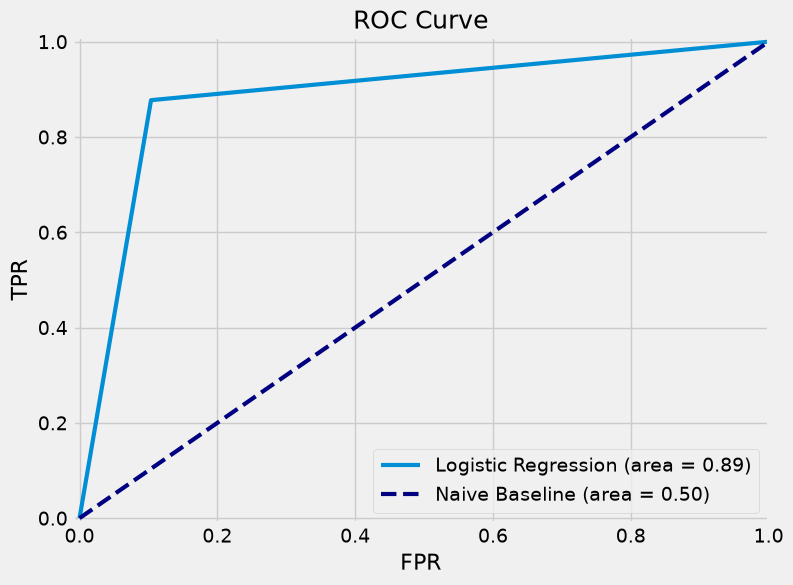

In [153]:
# ROC Curve

# predict() gives you hard 0/1 predictions. For an ROC curve, we generally want the model's probability scores, so that the threshold can vary.
fpr, tpr, _ = roc_curve(y_test, log_mod.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title('ROC Curve', fontsize=18)
plt.xlabel('FPR', fontsize=16)
plt.ylabel('TPR', fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr, tpr, lw=3, label='Logistic Regression (area = {:0.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--', label='Naive Baseline (area = 0.50)')
plt.legend(loc='lower right', fontsize=14)
plt.show()

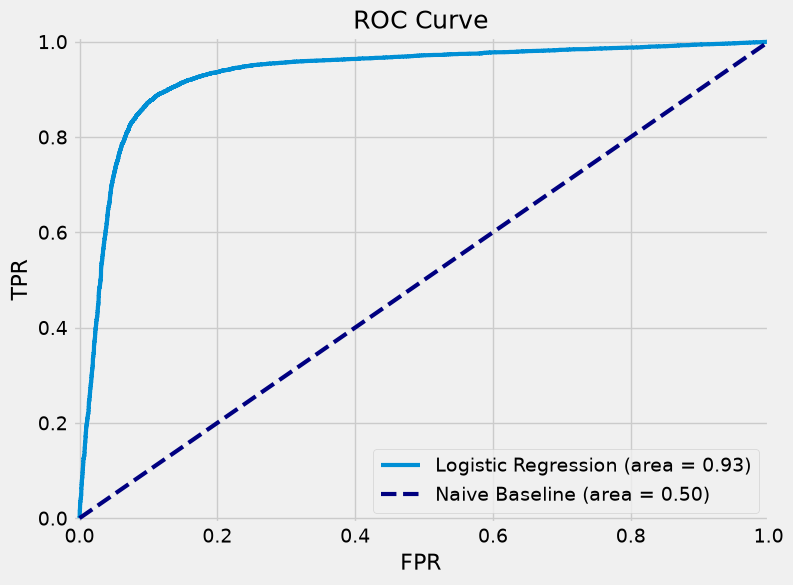

In [154]:
# ROC Curve
# predict_proba() gives us the actual prediction PROBABILITIES.
fpr, tpr, _ = roc_curve(
    y_test,
    log_mod.predict_proba(X_test)[:, 1]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title('ROC Curve', fontsize=18)
plt.xlabel('FPR', fontsize=16)
plt.ylabel('TPR', fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])

plt.plot(
    fpr,
    tpr,
    lw=3,
    label='Logistic Regression (area = {:0.2f})'.format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=3,
    linestyle='--',
    label='Naive Baseline (area = 0.50)'
)

plt.legend(loc='lower right', fontsize=14)
plt.show()

## K Nearest Neighbors

Takes up too much memory. Can only run on Anaconda.

In [155]:
from sklearn.neighbors import KNeighborsClassifier

In [156]:
# p = 2 for Euclidean Distance, Looks at 5 nearest Pokemon battles when making a prediction
knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)

In [157]:
knn_fit = knn.fit(X_train, y_train)

In [158]:
knn_test_preds = knn_fit.predict(X_test)

In [159]:
knn_acc = accuracy_score(y_test, knn_test_preds)
knn_acc

0.8753939393939394

### KNN Precision, Recall, & F1 Score

In [160]:
print(classification_report(y_test, knn_test_preds))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      8712
           1       0.87      0.87      0.87      7788

    accuracy                           0.88     16500
   macro avg       0.87      0.88      0.88     16500
weighted avg       0.88      0.88      0.88     16500



In [161]:
# KNN Precision
knn_prec = precision_score(y_test, knn_test_preds)
knn_prec

0.8668714797747056

In [162]:
# KNN Recall
knn_rec = recall_score(y_test, knn_test_preds)
knn_rec

0.869542886492039

In [163]:
# F1 Score by Hand
knn_f1 = 2 * ((knn_prec*knn_rec)/ (knn_prec+knn_rec))
knn_f1

0.8682051282051283

In [164]:
# Confusion Matrix.
knn_cm = confusion_matrix(y_test, knn_test_preds)
print ("KNN Confusion Matrix: \n", knn_cm)

KNN Confusion Matrix: 
 [[7672 1040]
 [1016 6772]]


### KNN TPR and FPR

In [165]:
# TPR for KNN Model
knn_tpr = knn_cm.ravel()[3]/(knn_cm.ravel()[3]+knn_cm.ravel()[2])
knn_tpr

np.float64(0.869542886492039)

In [166]:
# FPR for KNN Model
knn_fpr = knn_cm.ravel()[1]/(knn_cm.ravel()[1]+knn_cm.ravel()[0])
knn_fpr

np.float64(0.11937557392102846)

### KNN Sensitivity and Specificity

In [167]:
# KNN Sensitivity
knn_sen = recall_score(y_test, knn_test_preds)
knn_sen

0.869542886492039

In [168]:
# KNN Specificity
knn_spec = knn_cm.ravel()[0]/(knn_cm.ravel()[0]+knn_cm.ravel()[1])
knn_spec

np.float64(0.8806244260789715)

### KNN TNR and FNR

In [169]:
# KNN TNR
knn_tnr = knn_cm.ravel()[0]/(knn_cm.ravel()[0]+knn_cm.ravel()[1])
knn_tnr

np.float64(0.8806244260789715)

In [170]:
# KNN FNR
knn_fnr = knn_cm.ravel()[2]/(knn_cm.ravel()[2]+knn_cm.ravel()[3])
knn_fnr

np.float64(0.13045711350796096)

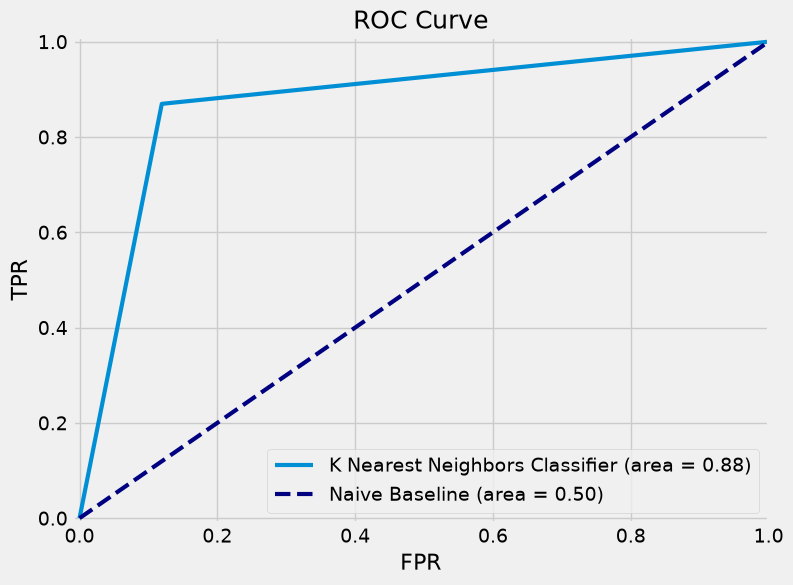

In [171]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, knn_test_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title('ROC Curve', fontsize=18)
plt.xlabel('FPR', fontsize=16)
plt.ylabel('TPR', fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr, tpr, lw=3, label='K Nearest Neighbors Classifier (area = {:0.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--', label='Naive Baseline (area = 0.50)')
plt.legend(loc='lower right', fontsize=14)
plt.show()

### Decision Tree Classifier

In [172]:
dtc = DecisionTreeClassifier()
dtc

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [174]:
dtc_fit = dtc.fit(X_train, y_train)
dtc_fit

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [175]:
dtc_test_preds = dtc_fit.predict(X_test)

In [176]:
dtc_test_preds

array([0, 0, 0, ..., 1, 1, 0], shape=(16500,))

In [177]:
dtc_acc = accuracy_score(y_test, dtc_test_preds)
dtc_acc

0.9470909090909091

### Decision Tree Classifier Precision and Recall

In [178]:
# DTC Precision
dtc_prec = precision_score(y_test, dtc_test_preds)
dtc_prec

0.9473411825591926

In [179]:
# DTC Recall
dtc_rec = recall_score(y_test, dtc_test_preds)
dtc_rec

0.9401643554185927

In [180]:
# F1 Score by Hand
dtc_f1 = 2 * ((dtc_prec*dtc_rec)/ (dtc_prec+dtc_rec))
dtc_f1

0.9437391248308307

In [181]:
# Confusion Matrix.
dtc_cm = confusion_matrix(y_test, dtc_test_preds)
print ("Decision Tree Classifer Confusion Matrix: \n", dtc_cm)

Decision Tree Classifer Confusion Matrix: 
 [[8305  407]
 [ 466 7322]]


### Decision Tree Classifier TPR and FPR

In [182]:
# TPR for Decision Tree Classifier Model
dtc_tpr = dtc_cm.ravel()[3]/(dtc_cm.ravel()[3]+dtc_cm.ravel()[2])
dtc_tpr

np.float64(0.9401643554185927)

In [183]:
# FPR for Decision Tree Classifier Model
dtc_fpr = dtc_cm.ravel()[1]/(dtc_cm.ravel()[1]+dtc_cm.ravel()[0])
dtc_fpr

np.float64(0.04671717171717172)

### Decision Tree Classifier Sensitivity and Specificity

In [184]:
# DTC Sensitivity
dtc_sen = recall_score(y_test, dtc_test_preds)
dtc_sen

0.9401643554185927

In [185]:
# DTC Specificity
dtc_spec = dtc_cm.ravel()[0]/(dtc_cm.ravel()[0]+dtc_cm.ravel()[1])
dtc_spec

np.float64(0.9532828282828283)

### Decision Tree Classifier TNR and FNR

In [186]:
# DTC TNR
dtc_tnr = dtc_cm.ravel()[0]/(dtc_cm.ravel()[0]+dtc_cm.ravel()[1])
dtc_tnr

np.float64(0.9532828282828283)

In [187]:
# DTC FNR
dtc_fnr = dtc_cm.ravel()[2]/(dtc_cm.ravel()[2]+dtc_cm.ravel()[3])
dtc_fnr

np.float64(0.05983564458140729)

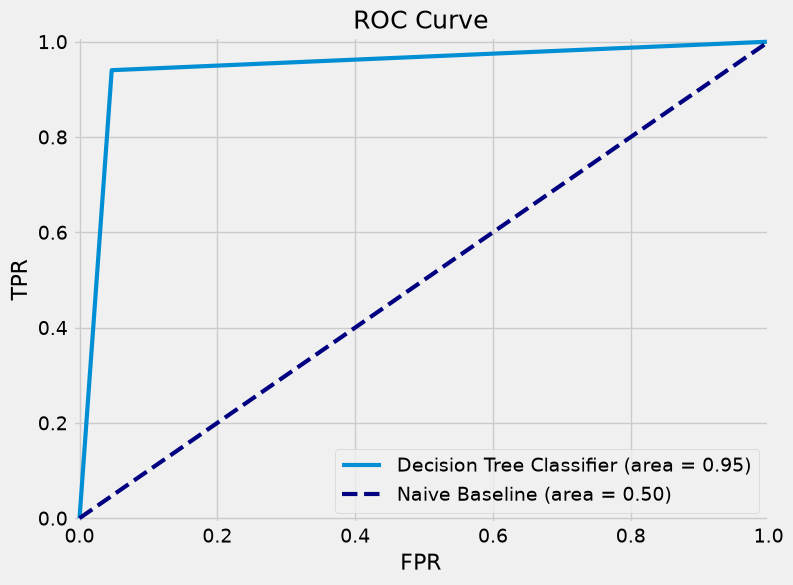

In [188]:
# Decision Tree Classifier ROC Curve
fpr, tpr, _ = roc_curve(y_test, dtc_test_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title('ROC Curve', fontsize=18)
plt.xlabel('FPR', fontsize=16)
plt.ylabel('TPR', fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr, tpr, lw=3, label='Decision Tree Classifier (area = {:0.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--', label='Naive Baseline (area = 0.50)')
plt.legend(loc='lower right', fontsize=14)
plt.show()

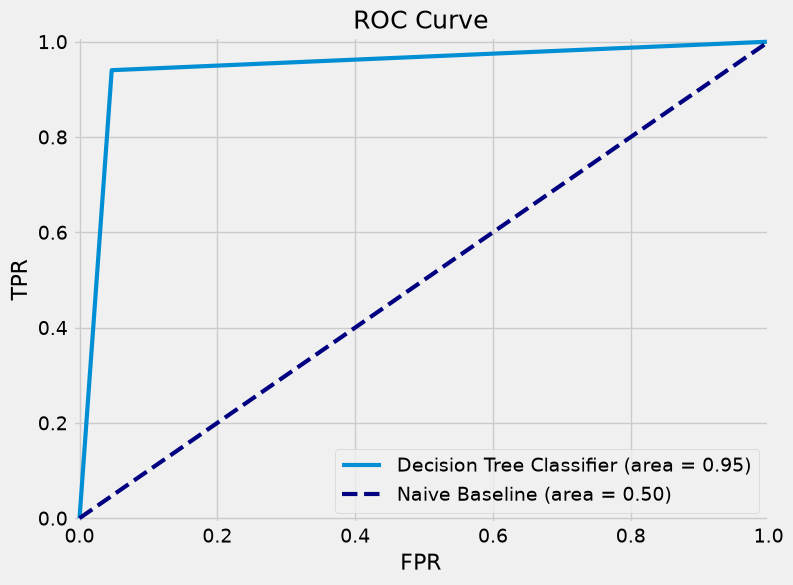

In [189]:
# Decision Tree Classifier ROC Curve
dtc_probs = dtc.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, dtc_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title('ROC Curve', fontsize=18)
plt.xlabel('FPR', fontsize=16)
plt.ylabel('TPR', fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])

plt.plot(
    fpr,
    tpr,
    lw=3,
    label='Decision Tree Classifier (area = {:0.2f})'.format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=3,
    linestyle='--',
    label='Naive Baseline (area = 0.50)'
)

plt.legend(loc='lower right', fontsize=14)
plt.show()

In [190]:
print(classification_report(y_test, dtc_test_preds))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      8712
           1       0.95      0.94      0.94      7788

    accuracy                           0.95     16500
   macro avg       0.95      0.95      0.95     16500
weighted avg       0.95      0.95      0.95     16500



## Random Forest Classifier

In [192]:
X_train.head()

,HP 1st,Attack 1st,Defense 1st,Sp. Atk 1st,Sp. Def 1st,Speed 1st,Type 1_Bug 1st,Type 1_Dark 1st,Type 1_Dragon 1st,Type 1_Electric 1st,...,Type 2_Rock 2nd,Type 2_Steel 2nd,Type 2_Water 2nd,Generation_1 2nd,Generation_2 2nd,Generation_3 2nd,Generation_4 2nd,Generation_5 2nd,Generation_6 2nd,Legendary 2nd
902,60,55,50,40,55,45,True,False,False,False,...,False,False,False,False,True,False,False,False,False,0
33864,55,65,95,95,45,85,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
5008,95,125,79,60,100,81,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0
21692,58,50,145,95,105,30,False,False,False,False,...,False,True,False,False,False,False,True,False,False,0
4336,80,80,50,40,50,25,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0


In [193]:
# 42 minutes to run
# grid_values = {"max_features": np.linspace(1, 38, 5, dtype="int32"), 
#               "min_samples_leaf": [5], 
#               "n_estimators": [500], 
#               "random_state": [42]}

grid_values = {"max_features": np.linspace(1, 100, 10, dtype="int32"), 
              "min_samples_leaf": [5], 
              "n_estimators": [500], 
              "random_state": [42]}


tic = time.time()

rf = RandomForestClassifier()

# Note: here we set verbose=2 to keep track of the progress (the running time) of the cross validation. 
cv = KFold(n_splits=5, random_state=42, shuffle=True)

rf_cv = GridSearchCV(rf, param_grid=grid_values, scoring="accuracy", cv=cv,verbose=2)

rf_cv.fit(X_train, y_train)

toc = time.time()

print("time:", round(toc-tic, 2),"s")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=42; total time=   3.8s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=42; total time=   3.4s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=42; total time=   3.6s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=42; total time=   3.6s
[CV] END max_features=1, min_samples_leaf=5, n_estimators=500, random_state=42; total time=   3.4s
[CV] END max_features=12, min_samples_leaf=5, n_estimators=500, random_state=42; total time=  12.0s
[CV] END max_features=12, min_samples_leaf=5, n_estimators=500, random_state=42; total time=  11.7s
[CV] END max_features=12, min_samples_leaf=5, n_estimators=500, random_state=42; total time=  11.8s
[CV] END max_features=12, min_samples_leaf=5, n_estimators=500, random_state=42; total time=  12.0s
[CV] END max_features=12, min_samples_leaf=5

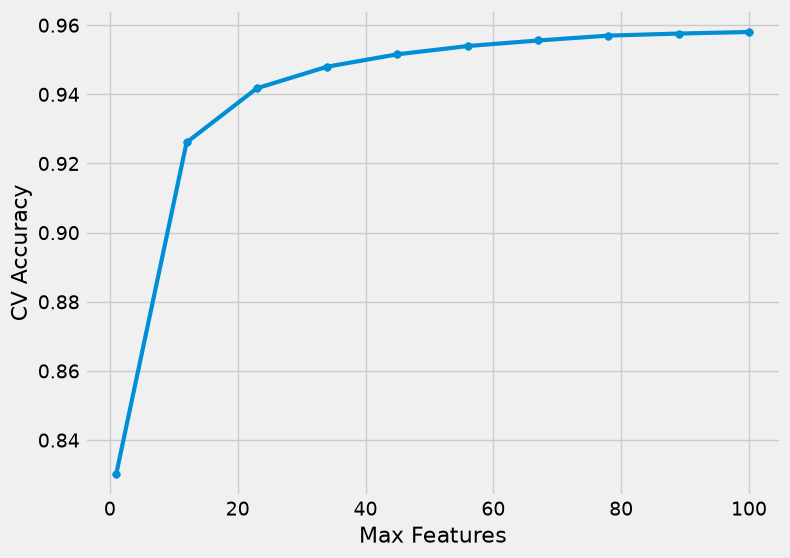

In [194]:
# Plotting the graph to determine the best hyperparameter 'm'
max_features = rf_cv.cv_results_["param_max_features"].data
R2_scores = rf_cv.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 6))
plt.xlabel("Max Features", fontsize=16)
plt.ylabel("CV Accuracy", fontsize=16)
plt.scatter(max_features, R2_scores, s=30)
plt.plot(max_features, R2_scores, linewidth=3)
plt.grid(True, which="both")

In [195]:
print(rf_cv.best_params_)

{'max_features': np.int32(100), 'min_samples_leaf': 5, 'n_estimators': 500, 'random_state': 42}


In [196]:
rf_test_preds = (rf_cv.predict(X_test))

In [197]:
rf_acc = accuracy_score(y_test, rf_test_preds)
rf_acc

0.9637575757575758

### Random Forest Precision and Recall

In [198]:
# Random Forest Precision
rf_prec = precision_score(y_test, rf_test_preds)
rf_prec

0.958662924215361

In [199]:
# Random Forest Recall
rf_rec = recall_score(y_test, rf_test_preds)
rf_rec

0.9648176682074987

In [200]:
# F1 Score by Hand
rf_f1 = 2 * ((rf_prec*rf_rec)/ (rf_prec+rf_rec))
rf_f1

0.961730449251248

In [201]:
# Confusion Matrix.
rf_cm = confusion_matrix(y_test, rf_test_preds)
print (f"Random Forest Confusion Matrix: \n {rf_cm}")

Random Forest Confusion Matrix: 
 [[8388  324]
 [ 274 7514]]


### Random Forest TPR and FPR

In [202]:
# TPR for Random Forest Model
rf_tpr = rf_cm.ravel()[3]/(rf_cm.ravel()[3]+rf_cm.ravel()[2])
rf_tpr

np.float64(0.9648176682074987)

In [203]:
# FPR for Random Forest Model
rf_fpr = rf_cm.ravel()[1]/(rf_cm.ravel()[1]+rf_cm.ravel()[0])
rf_fpr

np.float64(0.0371900826446281)

### Random Forest Sensitivity and Specificity

In [204]:
# Random Forest Sensitivity
rf_sen = recall_score(y_test, rf_test_preds)
rf_sen

0.9648176682074987

In [205]:
# Random Forest Specificity
rf_spec = rf_cm.ravel()[0]/(rf_cm.ravel()[0]+rf_cm.ravel()[1])
rf_spec

np.float64(0.9628099173553719)

### Random Forest TNR and FNR

In [206]:
# Random Forest TNR
rf_tnr = rf_cm.ravel()[0]/(rf_cm.ravel()[0]+rf_cm.ravel()[1])
rf_tnr

np.float64(0.9628099173553719)

In [207]:
# Random Forest FNR
rf_fnr = rf_cm.ravel()[2]/(rf_cm.ravel()[2]+rf_cm.ravel()[3])
rf_fnr

np.float64(0.035182331792501284)

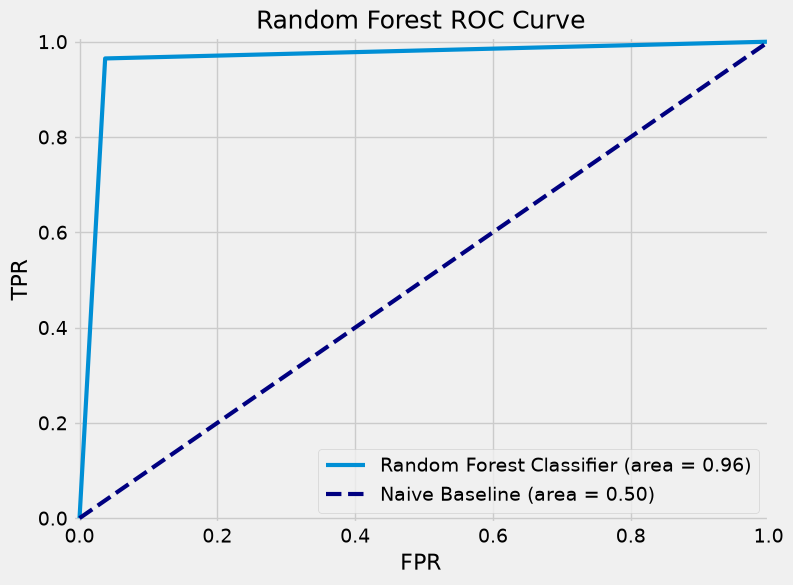

In [208]:
# Random Forest ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_test_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title("Random Forest ROC Curve", fontsize=18)
plt.xlabel("FPR", fontsize=16)
plt.ylabel("TPR", fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr, tpr, lw=3, label="Random Forest Classifier (area = {:0.2f})".format(roc_auc))
plt.plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--", label="Naive Baseline (area = 0.50)")
plt.legend(loc="lower right", fontsize=14)
plt.show()

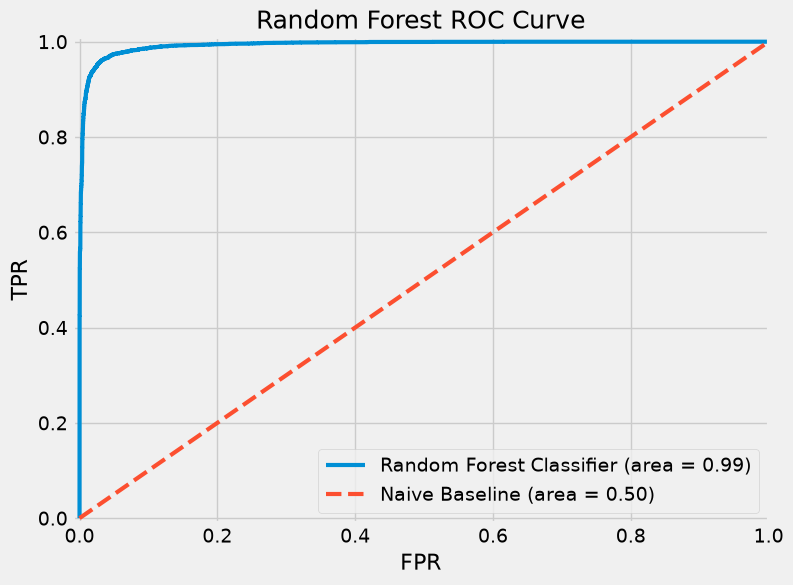

In [209]:
rf_probs = rf_cv.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.title("Random Forest ROC Curve", fontsize=18)
plt.xlabel("FPR", fontsize=16)
plt.ylabel("TPR", fontsize=16)
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])

plt.plot(
    fpr,
    tpr,
    lw=3,
    label="Random Forest Classifier (area = {:0.2f})".format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    lw=3,
    linestyle="--",
    label="Naive Baseline (area = 0.50)"
)

plt.legend(loc="lower right", fontsize=14)
plt.show()

In [210]:
print(classification_report(y_test, rf_test_preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      8712
           1       0.96      0.96      0.96      7788

    accuracy                           0.96     16500
   macro avg       0.96      0.96      0.96     16500
weighted avg       0.96      0.96      0.96     16500



### Metrics Table

In [211]:
import jinja2
print(jinja2.__version__)

3.1.6


In [212]:
rf_auc = auc(*roc_curve(y_test, rf_cv.predict_proba(X_test)[:, 1])[:2])

dtc_auc = auc(*roc_curve(y_test, dtc.predict_proba(X_test)[:, 1])[:2])

log_auc = auc(*roc_curve(y_test, log_mod.predict_proba(X_test)[:, 1])[:2])

knn_auc = auc(*roc_curve(y_test, knn.predict_proba(X_test)[:, 1])[:2])

In [213]:
rf_auc, dtc_acc

(0.9933750883726371, 0.9470909090909091)

In [216]:
comparison_data = {"Random Forest Classifier": ['{:.3f}'.format(rf_acc),
                                              '{:.4f}'.format(rf_tpr),
                                              '{:.3f}'.format(rf_fpr), 
                                               '{:.3f}'.format(rf_prec), 
                                               '{:.4f}'.format(rf_rec), 
                                                '{:.4f}'.format(rf_sen), 
                                                '{:.4f}'.format(rf_spec), 
                                                '{:.4f}'.format(rf_tnr), 
                                                '{:.4f}'.format(rf_fnr), 
                                               '{:.4f}'.format(rf_f1), 
                                               '{:.3f}'.format(rf_auc)], 
                   "Decision Tree Classifier":  ['{:.3f}'.format(dtc_acc),
                                              '{:.4f}'.format(dtc_tpr),
                                              '{:.3f}'.format(dtc_fpr), 
                                          '{:.3f}'.format(dtc_prec), 
                                          '{:.4f}'.format(dtc_rec), 
                                           '{:.4f}'.format(dtc_sen), 
                                           '{:.4f}'.format(dtc_spec),
                                           '{:.4f}'.format(dtc_tnr),
                                           '{:.4f}'.format(dtc_fnr), 
                                          '{:.4f}'.format(dtc_f1), 
                                          '{:.3f}'.format(dtc_auc)],
                  "Logistic Regression":  ['{:.3f}'.format(log_acc),
                                              '{:.4f}'.format(log_tpr),
                                              '{:.3f}'.format(log_fpr), 
                                          '{:.3f}'.format(log_prec), 
                                          '{:.4f}'.format(log_rec), 
                                           '{:.4f}'.format(log_sen), 
                                           '{:.4f}'.format(log_spec),
                                           '{:.4f}'.format(log_tnr),
                                           '{:.4f}'.format(log_fnr), 
                                          '{:.4f}'.format(log_f1), 
                                          '{:.3f}'.format(log_auc)], 
                  "K Nearest Neighbors":  ['{:.3f}'.format(knn_acc),
                                              '{:.4f}'.format(knn_tpr),
                                              '{:.3f}'.format(knn_fpr), 
                                          '{:.3f}'.format(knn_prec), 
                                          '{:.4f}'.format(knn_rec), 
                                           '{:.4f}'.format(knn_sen),
                                           '{:.4f}'.format(knn_spec),
                                           '{:.4f}'.format(knn_tnr),
                                           '{:.4f}'.format(knn_fnr),
                                          '{:.4f}'.format(knn_f1), 
                                          '{:.3f}'.format(knn_auc)]}


comparison_table = pd.DataFrame(data=comparison_data, index=['Accuracy', 'TPR', 'FPR', 'Precision', 'Recall', 
                                                             'Sensitivity', 'Specificity', 'TNR', 'FNR', 'F1 Score', 'ROC-AUC'])
comparison_table.style.set_properties(**{'font-size': '12pt',}).set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}])

,Random Forest Classifier,Decision Tree Classifier,Logistic Regression,K Nearest Neighbors
Accuracy,0.964,0.947,0.887,0.875
TPR,0.9648,0.9402,0.8772,0.8695
FPR,0.037,0.047,0.104,0.119
Precision,0.959,0.947,0.883,0.867
Recall,0.9648,0.9402,0.8772,0.8695
Sensitivity,0.9648,0.9402,0.8772,0.8695
Specificity,0.9628,0.9533,0.8962,0.8806
TNR,0.9628,0.9533,0.8962,0.8806
FNR,0.0352,0.0598,0.1228,0.1305
F1 Score,0.9617,0.9437,0.8802,0.8682
